# Optimizers Deep Dive: SGD, Momentum, RMSprop & Adam

## Learning Objectives

By the end of this notebook, you will:

1. **Understand** the fundamental problem each optimizer solves
2. **Build intuition** for how SGD, Momentum, RMSprop, and Adam work differently
3. **Visualize** optimization trajectories on different loss landscapes
4. **Implement** each optimizer from scratch
5. **Compare** their behavior on real neural network training
6. **Know** when to use each optimizer in practice

**Philosophy**: This notebook emphasizes intuition over mathematical rigor. We'll build understanding step-by-step through visualization, experimentation, and hands-on implementation.

## Part 1: Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from mpl_toolkits.mplot3d import Axes3D
from aiml_notebooks import get_device, set_seed

# Set random seed for reproducibility
set_seed(42)

# Get device
device = get_device()

# Plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

Using CUDA GPU: NVIDIA GeForce RTX 4090


## Part 2: The Optimization Problem

### What are we trying to do?

In machine learning, we want to minimize a loss function $L(\theta)$ by adjusting parameters $\theta$.

**Analogy**: Imagine you're blindfolded on a hilly terrain and want to reach the lowest valley. You can only:
- Feel the slope beneath your feet (gradient)
- Take steps in any direction

**Different optimizers = different strategies for navigating this terrain**

Let's visualize some challenging loss landscapes that optimizers must navigate.

In [2]:
# Define various loss functions to test optimizers

def simple_quadratic(x, y):
    """Simple bowl-shaped function (easy to optimize)"""
    return x**2 + y**2

def elongated_bowl(x, y):
    """Elongated bowl (ravine) - tests handling of different scales"""
    return x**2 + 10*y**2

def beale(x, y):
    """Beale function - multimodal, challenging"""
    return (1.5 - x + x*y)**2 + (2.25 - x + x*y**2)**2 + (2.625 - x + x*y**3)**2

def rosenbrock(x, y, a=1, b=100):
    """Rosenbrock function - narrow valley, very challenging"""
    return (a - x)**2 + b*(y - x**2)**2

def saddle_point(x, y):
    """Saddle point function - x^2 - y^2"""
    return x**2 - y**2

Visualize the results with multiple plots for comparison.

In [3]:
# Visualize the loss landscapes

def plot_surface_3d(func, x_range=(-2, 2), y_range=(-2, 2), title="", resolution=100):
    """Plot a 3D surface of the loss function"""
    x = np.linspace(*x_range, resolution)
    y = np.linspace(*y_range, resolution)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)
    
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, edgecolor='none')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('Loss')
    ax.set_title(title)
    return fig, ax

def plot_contour(func, x_range=(-2, 2), y_range=(-2, 2), title="", resolution=100, levels=20):
    """Plot a 2D contour of the loss function"""
    x = np.linspace(*x_range, resolution)
    y = np.linspace(*y_range, resolution)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)
    
    plt.figure(figsize=(8, 6))
    contour = plt.contour(X, Y, Z, levels=levels, cmap='viridis')
    plt.colorbar(contour, label='Loss')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    return X, Y, Z

Visualize the results with multiple plots for comparison.

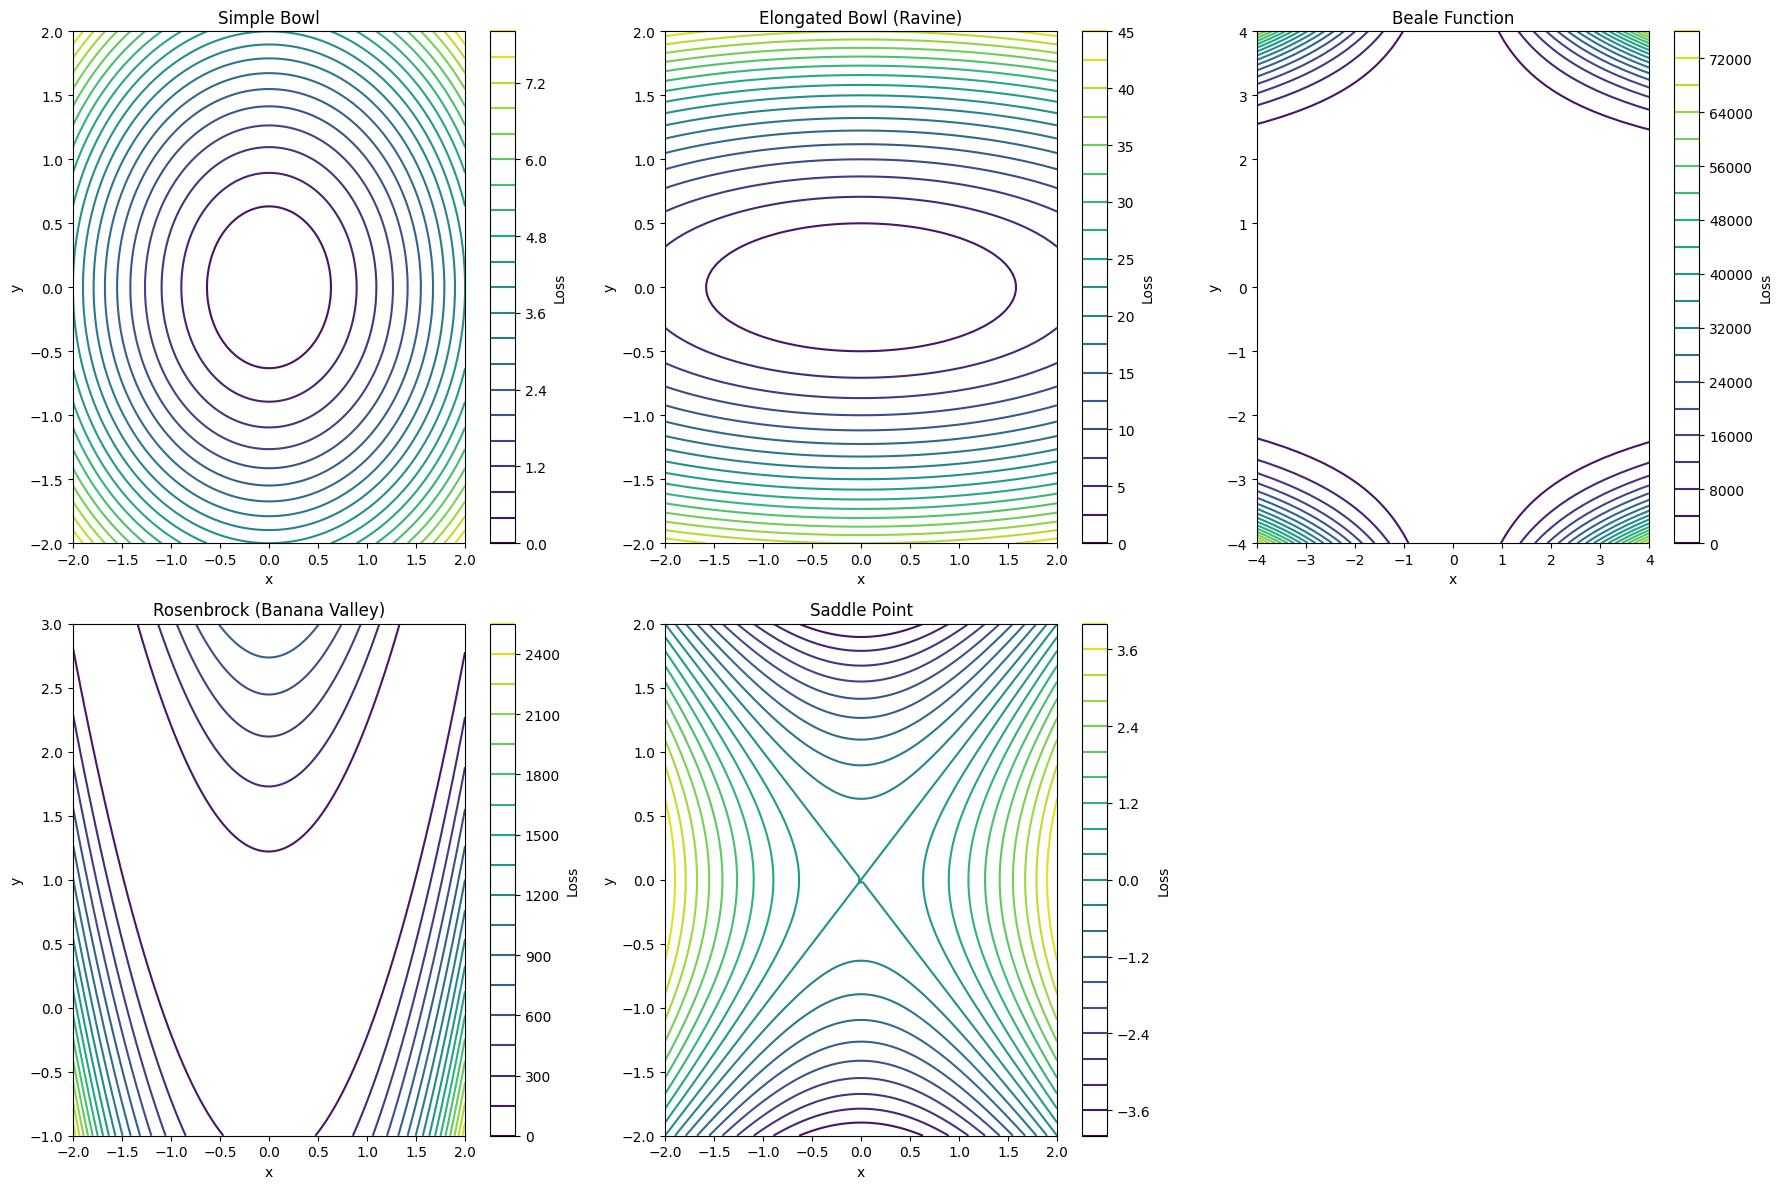

These are the challenges optimizers must navigate:
- Simple Bowl: Easy, gradient points directly to minimum
- Elongated Bowl: Different scales in x vs y (common in neural networks!)
- Beale: Multiple local minima, complex landscape
- Rosenbrock: Famous narrow valley that's hard to navigate
- Saddle Point: Flat in some directions, needs to escape saddle


In [4]:
# Visualize different loss landscapes
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

landscapes = [
    (simple_quadratic, (-2, 2), (-2, 2), "Simple Bowl"),
    (elongated_bowl, (-2, 2), (-2, 2), "Elongated Bowl (Ravine)"),
    (beale, (-4, 4), (-4, 4), "Beale Function"),
    (rosenbrock, (-2, 2), (-1, 3), "Rosenbrock (Banana Valley)"),
    (saddle_point, (-2, 2), (-2, 2), "Saddle Point"),
]

for idx, (func, x_range, y_range, title) in enumerate(landscapes):
    ax = axes[idx // 3, idx % 3]
    x = np.linspace(*x_range, 100)
    y = np.linspace(*y_range, 100)
    X, Y = np.meshgrid(x, y)
    Z = func(X, Y)
    
    contour = ax.contour(X, Y, Z, levels=20, cmap='viridis')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)
    plt.colorbar(contour, ax=ax, label='Loss')

# Hide the last subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("These are the challenges optimizers must navigate:")
print("- Simple Bowl: Easy, gradient points directly to minimum")
print("- Elongated Bowl: Different scales in x vs y (common in neural networks!)")
print("- Beale: Multiple local minima, complex landscape")
print("- Rosenbrock: Famous narrow valley that's hard to navigate")
print("- Saddle Point: Flat in some directions, needs to escape saddle")

### 🤔 Reflection Questions

1. Why might the elongated bowl be challenging for optimization?
2. What makes the Rosenbrock function difficult despite having a clear global minimum?
3. How might saddle points slow down optimization?

## Part 3: Stochastic Gradient Descent (SGD) - The Foundation

### The Idea

**SGD is the simplest optimizer**: Take steps in the opposite direction of the gradient.

$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$$

Where:
- $\theta_t$ = parameters at step $t$
- $\eta$ = learning rate (step size)
- $\nabla L(\theta_t)$ = gradient of loss w.r.t. parameters

**Analogy**: Feel the slope, take a step downhill. That's it!

### Strengths
- Simple and reliable
- Low memory usage
- Works well with proper learning rate

### Weaknesses
- Sensitive to learning rate choice
- Slow in ravines (elongated valleys)
- Oscillates in narrow valleys
- Same learning rate for all parameters

In [5]:
# Implement SGD from scratch

class SGD:
    def __init__(self, lr=0.01):
        """
        Stochastic Gradient Descent optimizer
        
        Args:
            lr: Learning rate (step size)
        """
        self.lr = lr
    
    def step(self, params, grads):
        """
        Update parameters using gradients
        
        Args:
            params: Current parameters [x, y]
            grads: Gradients [dx, dy]
        
        Returns:
            Updated parameters
        """
        return params - self.lr * grads

print("✓ SGD implementation complete")
print(f"\nAlgorithm: θ_new = θ - η * ∇L")
print(f"Memory: O(1) - no state to maintain")

✓ SGD implementation complete

Algorithm: θ_new = θ - η * ∇L
Memory: O(1) - no state to maintain


Display training results and metrics.

In [6]:
# Helper function to compute numerical gradients

def compute_gradient(func, x, y, epsilon=1e-5):
    """
    Compute gradient using finite differences
    
    Args:
        func: Loss function
        x, y: Current position
        epsilon: Small step for numerical gradient
    
    Returns:
        Gradient [dx, dy]
    """
    dx = (func(x + epsilon, y) - func(x - epsilon, y)) / (2 * epsilon)
    dy = (func(x, y + epsilon) - func(x, y - epsilon)) / (2 * epsilon)
    return np.array([dx, dy])

# Test gradient computation
x, y = 1.0, 1.0
grad = compute_gradient(simple_quadratic, x, y)
print(f"Gradient at ({x}, {y}): {grad}")
print(f"Expected: [2.0, 2.0] (for f(x,y) = x² + y²)")

Gradient at (1.0, 1.0): [2. 2.]
Expected: [2.0, 2.0] (for f(x,y) = x² + y²)


Display training results and metrics.

In [7]:
# Optimization runner

def optimize(func, optimizer, start_pos, num_steps=100, x_range=(-2, 2), y_range=(-2, 2)):
    """
    Run optimizer on a function and track trajectory
    
    Args:
        func: Loss function to minimize
        optimizer: Optimizer instance
        start_pos: Starting position [x, y]
        num_steps: Number of optimization steps
        x_range, y_range: Bounds for gradient computation
    
    Returns:
        history: List of (x, y, loss) tuples
    """
    pos = np.array(start_pos, dtype=np.float64)
    history = [(pos[0], pos[1], func(pos[0], pos[1]))]
    
    for step in range(num_steps):
        # Compute gradient
        grad = compute_gradient(func, pos[0], pos[1])
        
        # Update parameters
        if hasattr(optimizer, 'step'):
            pos = optimizer.step(pos, grad)
        else:
            raise AttributeError(f"Optimizer {optimizer} must have a 'step' method")
        
        # Clip to bounds (prevent divergence)
        pos[0] = np.clip(pos[0], x_range[0], x_range[1])
        pos[1] = np.clip(pos[1], y_range[0], y_range[1])
        
        # Record
        loss = func(pos[0], pos[1])
        history.append((pos[0], pos[1], loss))
        
        # Early stopping if converged
        if step > 10 and abs(history[-1][2] - history[-2][2]) < 1e-8:
            break
    
    return history

print("✓ Optimization runner ready")

✓ Optimization runner ready


Plot a histogram to understand the distribution.

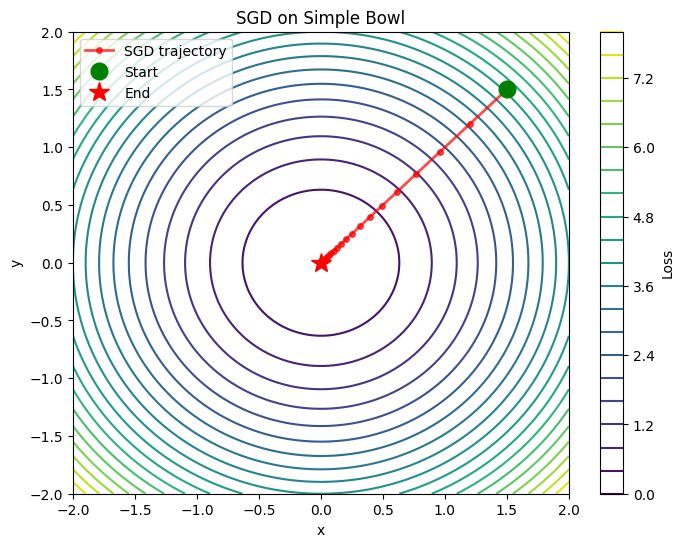

Started at: (1.50, 1.50)
Ended at: (0.0001, 0.0001)
Steps taken: 45
Final loss: 0.000000


In [8]:
# Test SGD on simple quadratic

optimizer_sgd = SGD(lr=0.1)
start = [1.5, 1.5]
history_sgd = optimize(simple_quadratic, optimizer_sgd, start, num_steps=50)

# Plot trajectory
X, Y, Z = plot_contour(simple_quadratic, title="SGD on Simple Bowl")

# Extract x, y coordinates from history
xs = [h[0] for h in history_sgd]
ys = [h[1] for h in history_sgd]

plt.plot(xs, ys, 'r.-', linewidth=2, markersize=8, label='SGD trajectory', alpha=0.7)
plt.plot(xs[0], ys[0], 'go', markersize=12, label='Start')
plt.plot(xs[-1], ys[-1], 'r*', markersize=15, label='End')
plt.legend()
plt.show()

print(f"Started at: ({start[0]:.2f}, {start[1]:.2f})")
print(f"Ended at: ({xs[-1]:.4f}, {ys[-1]:.4f})")
print(f"Steps taken: {len(history_sgd)}")
print(f"Final loss: {history_sgd[-1][2]:.6f}")

Plot a histogram to understand the distribution.

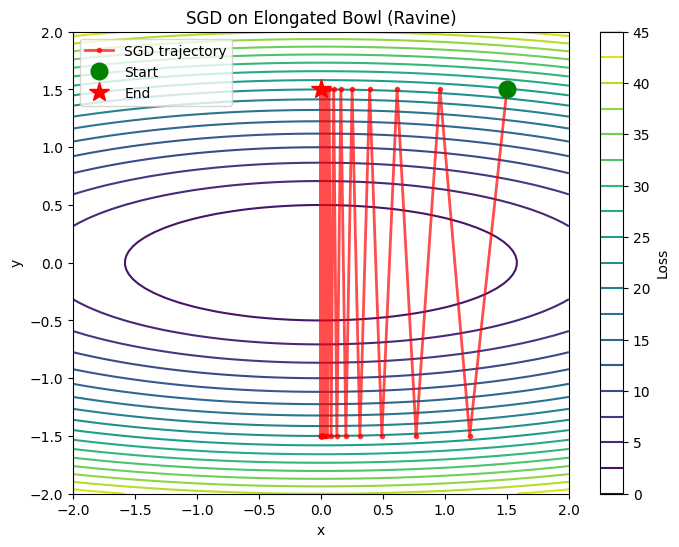

Started at: (1.50, 1.50)
Ended at: (0.0001, 1.5000)
Steps taken: 43
Final loss: 22.500000

⚠️  Notice the oscillations! SGD struggles with different scales.


In [9]:
# Test SGD on elongated bowl (challenging for SGD!)

optimizer_sgd = SGD(lr=0.1)
start = [1.5, 1.5]
history_sgd_elongated = optimize(elongated_bowl, optimizer_sgd, start, num_steps=100)

# Plot trajectory
X, Y, Z = plot_contour(elongated_bowl, title="SGD on Elongated Bowl (Ravine)")

xs = [h[0] for h in history_sgd_elongated]
ys = [h[1] for h in history_sgd_elongated]

plt.plot(xs, ys, 'r.-', linewidth=2, markersize=6, label='SGD trajectory', alpha=0.7)
plt.plot(xs[0], ys[0], 'go', markersize=12, label='Start')
plt.plot(xs[-1], ys[-1], 'r*', markersize=15, label='End')
plt.legend()
plt.show()

print(f"Started at: ({start[0]:.2f}, {start[1]:.2f})")
print(f"Ended at: ({xs[-1]:.4f}, {ys[-1]:.4f})")
print(f"Steps taken: {len(history_sgd_elongated)}")
print(f"Final loss: {history_sgd_elongated[-1][2]:.6f}")
print("\n⚠️  Notice the oscillations! SGD struggles with different scales.")

### 🤔 Reflection Questions

1. Why does SGD oscillate in the elongated bowl?
2. What happens if the learning rate is too high? Too low?
3. How would you expect SGD to perform on the Rosenbrock function?

### 🧪 Try This!

Experiment with different learning rates in the cell below:

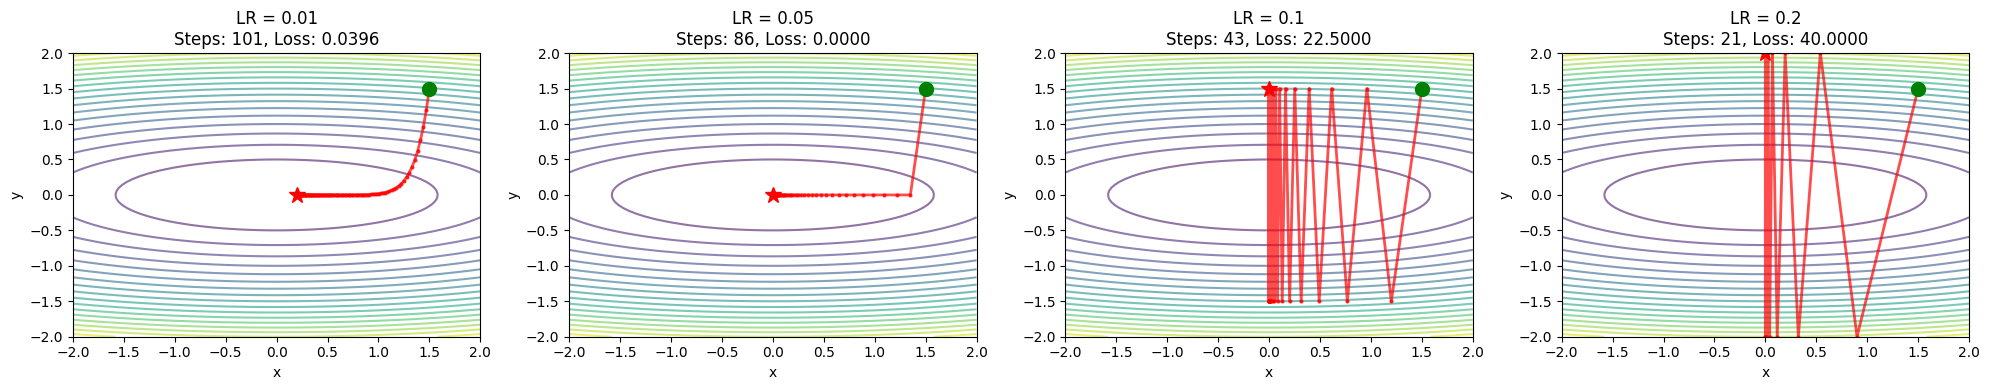

Observations:
- Too low LR → slow convergence
- Too high LR → more oscillations
- Sweet spot depends on the landscape!


In [10]:
# Experiment: Compare different learning rates

learning_rates = [0.01, 0.05, 0.1, 0.2]
start = [1.5, 1.5]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, lr in enumerate(learning_rates):
    ax = axes[idx]
    
    # Run optimizer
    optimizer = SGD(lr=lr)
    history = optimize(elongated_bowl, optimizer, start, num_steps=100)
    
    # Plot
    x = np.linspace(-2, 2, 100)
    y = np.linspace(-2, 2, 100)
    X, Y = np.meshgrid(x, y)
    Z = elongated_bowl(X, Y)
    
    contour = ax.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
    
    xs = [h[0] for h in history]
    ys = [h[1] for h in history]
    
    ax.plot(xs, ys, 'r.-', linewidth=2, markersize=4, alpha=0.7)
    ax.plot(xs[0], ys[0], 'go', markersize=10)
    ax.plot(xs[-1], ys[-1], 'r*', markersize=12)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'LR = {lr}\nSteps: {len(history)}, Loss: {history[-1][2]:.4f}')

plt.tight_layout()
plt.show()

print("Observations:")
print("- Too low LR → slow convergence")
print("- Too high LR → more oscillations")
print("- Sweet spot depends on the landscape!")

## Part 4: Momentum - Adding Velocity

### The Problem with SGD

SGD has **no memory** - each step ignores previous directions. This causes:
- Oscillations in narrow valleys
- Slow progress in flat regions
- Getting stuck in local minima or saddle points

### The Solution: Momentum

**Key Idea**: Accumulate a velocity vector that points in directions of persistent gradient.

$$v_{t+1} = \beta v_t + \nabla L(\theta_t)$$
$$\theta_{t+1} = \theta_t - \eta v_{t+1}$$

Where:
- $v_t$ = velocity (running average of gradients)
- $\beta$ = momentum coefficient (typically 0.9)
- $\eta$ = learning rate

**Analogy**: A heavy ball rolling down a hill - it builds up speed (momentum) in consistent directions and dampens oscillations in changing directions.

### How It Helps
- **Accelerates** in directions of consistent gradient
- **Dampens** oscillations in varying directions
- **Escapes** shallow local minima and saddle points
- **Navigates** ravines more smoothly

In [11]:
# Implement Momentum from scratch

class Momentum:
    def __init__(self, lr=0.01, beta=0.9):
        """
        SGD with Momentum optimizer
        
        Args:
            lr: Learning rate
            beta: Momentum coefficient (0 to 1)
        """
        self.lr = lr
        self.beta = beta
        self.v = None  # Velocity (initialized on first step)
    
    def step(self, params, grads):
        """
        Update parameters using momentum
        
        Args:
            params: Current parameters [x, y]
            grads: Gradients [dx, dy]
        
        Returns:
            Updated parameters
        """
        # Initialize velocity on first step
        if self.v is None:
            self.v = np.zeros_like(grads)
        
        # Update velocity: v = β*v + grad
        self.v = self.beta * self.v + grads
        
        # Update parameters: θ = θ - lr*v
        return params - self.lr * self.v

print("✓ Momentum implementation complete")
print(f"\nAlgorithm:")
print(f"  v = β*v + ∇L")
print(f"  θ_new = θ - η*v")
print(f"\nMemory: O(n) - stores velocity for each parameter")
print(f"Typical β: 0.9 (means 90% of previous velocity is retained)")

✓ Momentum implementation complete

Algorithm:
  v = β*v + ∇L
  θ_new = θ - η*v

Memory: O(n) - stores velocity for each parameter
Typical β: 0.9 (means 90% of previous velocity is retained)


Visualize the results with multiple plots for comparison.

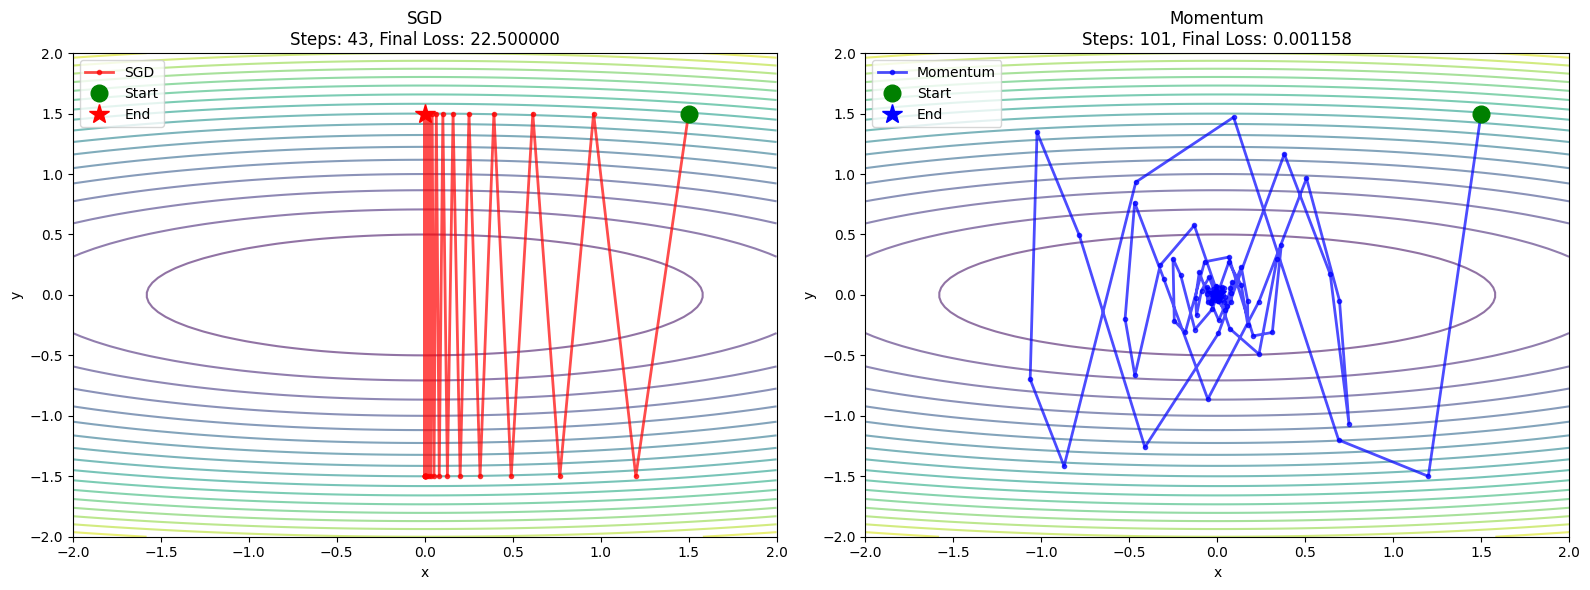

Key Differences:
- SGD: 43 steps, oscillates
- Momentum: 101 steps, smoother trajectory

✨ Momentum reduces oscillations by accumulating velocity!


In [12]:
# Compare SGD vs Momentum on elongated bowl

start = [1.5, 1.5]

# Run both optimizers
sgd = SGD(lr=0.1)
momentum = Momentum(lr=0.1, beta=0.9)

history_sgd = optimize(elongated_bowl, sgd, start, num_steps=100)
history_momentum = optimize(elongated_bowl, momentum, start, num_steps=100)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, history, title, color in [
    (axes[0], history_sgd, 'SGD', 'red'),
    (axes[1], history_momentum, 'Momentum', 'blue')
]:
    x = np.linspace(-2, 2, 100)
    y = np.linspace(-2, 2, 100)
    X, Y = np.meshgrid(x, y)
    Z = elongated_bowl(X, Y)
    
    contour = ax.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
    
    xs = [h[0] for h in history]
    ys = [h[1] for h in history]
    
    ax.plot(xs, ys, '.-', color=color, linewidth=2, markersize=6, alpha=0.7, label=title)
    ax.plot(xs[0], ys[0], 'go', markersize=12, label='Start')
    ax.plot(xs[-1], ys[-1], '*', color=color, markersize=15, label='End')
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{title}\nSteps: {len(history)}, Final Loss: {history[-1][2]:.6f}')
    ax.legend()

plt.tight_layout()
plt.show()

print("Key Differences:")
print(f"- SGD: {len(history_sgd)} steps, oscillates")
print(f"- Momentum: {len(history_momentum)} steps, smoother trajectory")
print("\n✨ Momentum reduces oscillations by accumulating velocity!")

Plot a histogram to understand the distribution.

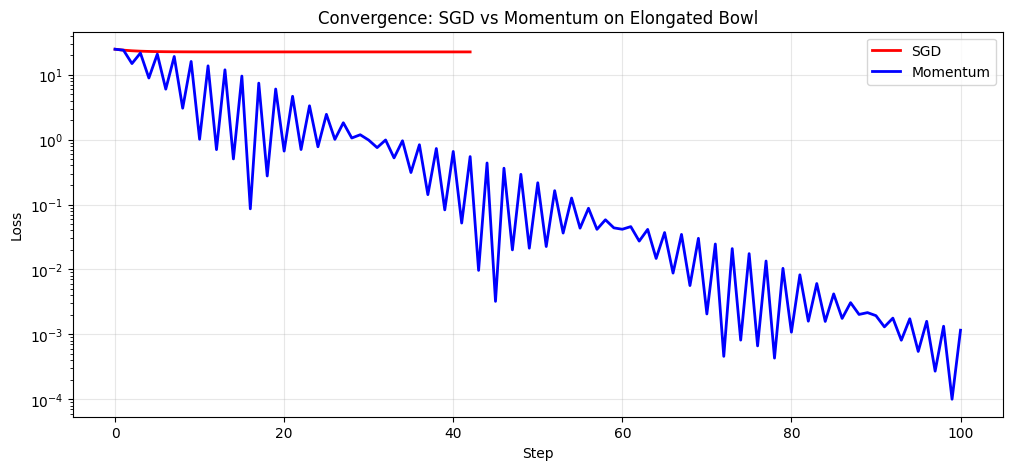

Notice: Momentum converges faster and more smoothly!


In [13]:
# Visualize momentum's effect over time

def plot_loss_curves(histories, labels, title="Loss Over Time"):
    """Plot loss curves for multiple optimization runs"""
    plt.figure(figsize=(12, 5))
    
    for history, label, color in zip(histories, labels, ['red', 'blue', 'green', 'orange']):
        losses = [h[2] for h in history]
        plt.plot(losses, label=label, color=color, linewidth=2)
    
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')  # Log scale to see details
    plt.show()

# Compare on elongated bowl
plot_loss_curves(
    [history_sgd, history_momentum],
    ['SGD', 'Momentum'],
    title='Convergence: SGD vs Momentum on Elongated Bowl'
)

print("Notice: Momentum converges faster and more smoothly!")

### Understanding the Momentum Coefficient β

The momentum coefficient $\beta$ controls how much "memory" the optimizer has:

- **β = 0**: No momentum (equivalent to SGD)
- **β = 0.9**: Retains 90% of previous velocity (typical)
- **β = 0.99**: Very high momentum, slow to change direction

**Effective window**: With β = 0.9, the optimizer "remembers" roughly the last 10 gradients.

Let's visualize this:

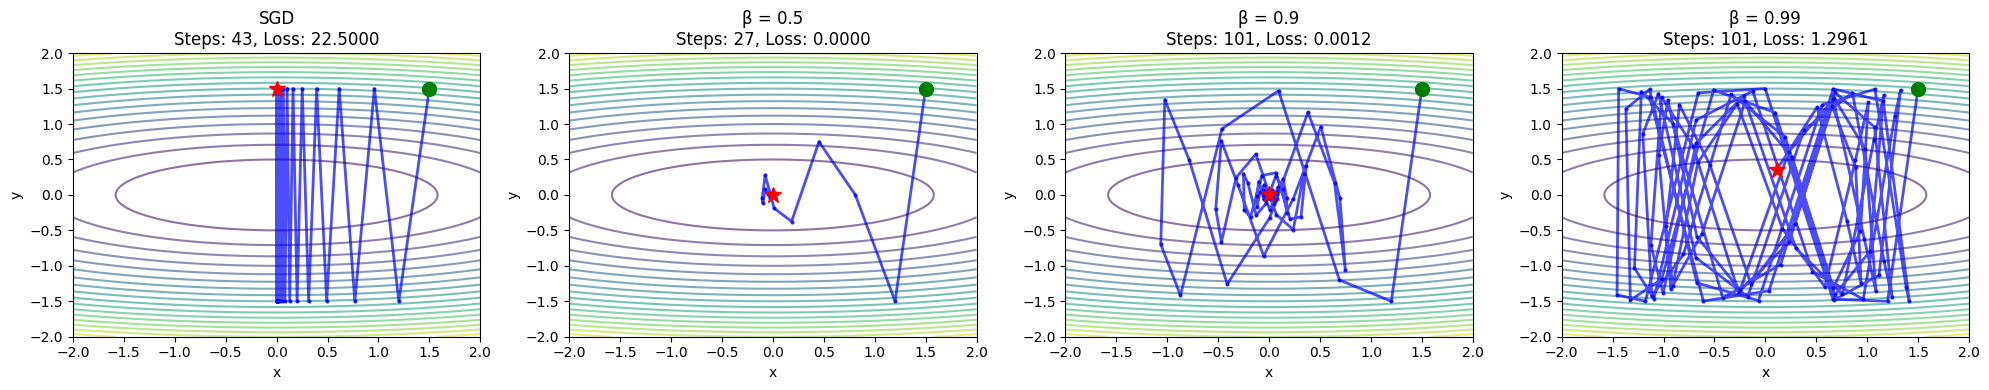

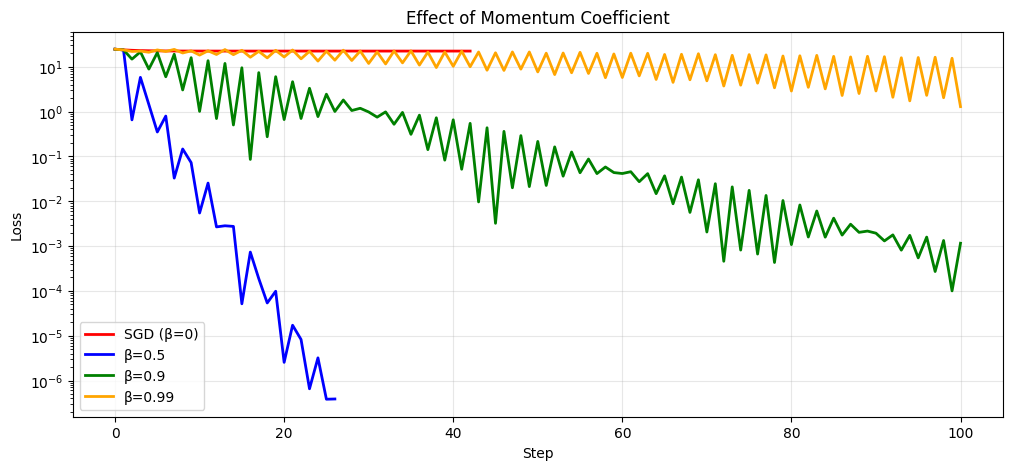

Observations:
- β=0.0 (SGD): Oscillates
- β=0.5: Less oscillation
- β=0.9: Smooth, fast convergence (sweet spot!)
- β=0.99: Very smooth, but can overshoot


In [14]:
# Experiment: Effect of momentum coefficient

betas = [0.0, 0.5, 0.9, 0.99]
start = [1.5, 1.5]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
histories = []

for idx, beta in enumerate(betas):
    ax = axes[idx]
    
    # Run optimizer
    if beta == 0.0:
        optimizer = SGD(lr=0.1)
    else:
        optimizer = Momentum(lr=0.1, beta=beta)
    
    history = optimize(elongated_bowl, optimizer, start, num_steps=100)
    histories.append(history)
    
    # Plot
    x = np.linspace(-2, 2, 100)
    y = np.linspace(-2, 2, 100)
    X, Y = np.meshgrid(x, y)
    Z = elongated_bowl(X, Y)
    
    contour = ax.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
    
    xs = [h[0] for h in history]
    ys = [h[1] for h in history]
    
    ax.plot(xs, ys, 'b.-', linewidth=2, markersize=4, alpha=0.7)
    ax.plot(xs[0], ys[0], 'go', markersize=10)
    ax.plot(xs[-1], ys[-1], 'r*', markersize=12)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    label = 'SGD' if beta == 0.0 else f'β = {beta}'
    ax.set_title(f'{label}\nSteps: {len(history)}, Loss: {history[-1][2]:.4f}')

plt.tight_layout()
plt.show()

# Loss curves
labels = ['SGD (β=0)', 'β=0.5', 'β=0.9', 'β=0.99']
plot_loss_curves(histories, labels, title='Effect of Momentum Coefficient')

print("Observations:")
print("- β=0.0 (SGD): Oscillates")
print("- β=0.5: Less oscillation")
print("- β=0.9: Smooth, fast convergence (sweet spot!)")
print("- β=0.99: Very smooth, but can overshoot")

### 🤔 Reflection Questions

1. Why does momentum help with ravines?
2. What could go wrong with very high momentum (β close to 1)?
3. When might you prefer vanilla SGD over momentum?

## Part 5: RMSprop - Adaptive Learning Rates

### The Problem

Both SGD and Momentum use the **same learning rate for all parameters**. But:
- Some parameters need large updates (flat regions)
- Some parameters need small updates (steep regions)
- Gradients can vary wildly in scale

### The Solution: RMSprop (Root Mean Square Propagation)

**Key Idea**: Adapt the learning rate for each parameter based on recent gradient magnitudes.

$$s_{t+1} = \beta s_t + (1 - \beta) (\nabla L(\theta_t))^2$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_{t+1} + \epsilon}} \nabla L(\theta_t)$$

Where:
- $s_t$ = running average of squared gradients
- $\beta$ = decay rate (typically 0.9 or 0.99)
- $\epsilon$ = small constant for numerical stability (typically 1e-8)

**Analogy**: Divide the learning rate by the "typical" magnitude of recent gradients - parameters with consistently large gradients get smaller effective learning rates.

### How It Helps
- **Normalizes** gradients across parameters
- **Adapts** to local geometry automatically
- **Handles** sparse gradients well
- **Works** well with non-stationary objectives

In [15]:
# Implement RMSprop from scratch

class RMSprop:
    def __init__(self, lr=0.01, beta=0.9, epsilon=1e-8):
        """
        RMSprop optimizer
        
        Args:
            lr: Learning rate
            beta: Decay rate for squared gradients
            epsilon: Small constant for numerical stability
        """
        self.lr = lr
        self.beta = beta
        self.epsilon = epsilon
        self.s = None  # Running average of squared gradients
    
    def step(self, params, grads):
        """
        Update parameters using RMSprop
        
        Args:
            params: Current parameters [x, y]
            grads: Gradients [dx, dy]
        
        Returns:
            Updated parameters
        """
        # Initialize on first step
        if self.s is None:
            self.s = np.zeros_like(grads)
        
        # Update running average of squared gradients
        self.s = self.beta * self.s + (1 - self.beta) * grads**2
        
        # Update parameters with adaptive learning rate
        # Note: Each parameter gets its own effective learning rate!
        adjusted_grad = grads / (np.sqrt(self.s) + self.epsilon)
        return params - self.lr * adjusted_grad

print("✓ RMSprop implementation complete")
print(f"\nAlgorithm:")
print(f"  s = β*s + (1-β)*∇L²")
print(f"  θ_new = θ - η * ∇L / (√s + ε)")
print(f"\nMemory: O(n) - stores squared gradient moving average")
print(f"Key insight: Divides by √(average gradient magnitude)")

✓ RMSprop implementation complete

Algorithm:
  s = β*s + (1-β)*∇L²
  θ_new = θ - η * ∇L / (√s + ε)

Memory: O(n) - stores squared gradient moving average
Key insight: Divides by √(average gradient magnitude)


Visualize the results with multiple plots for comparison.

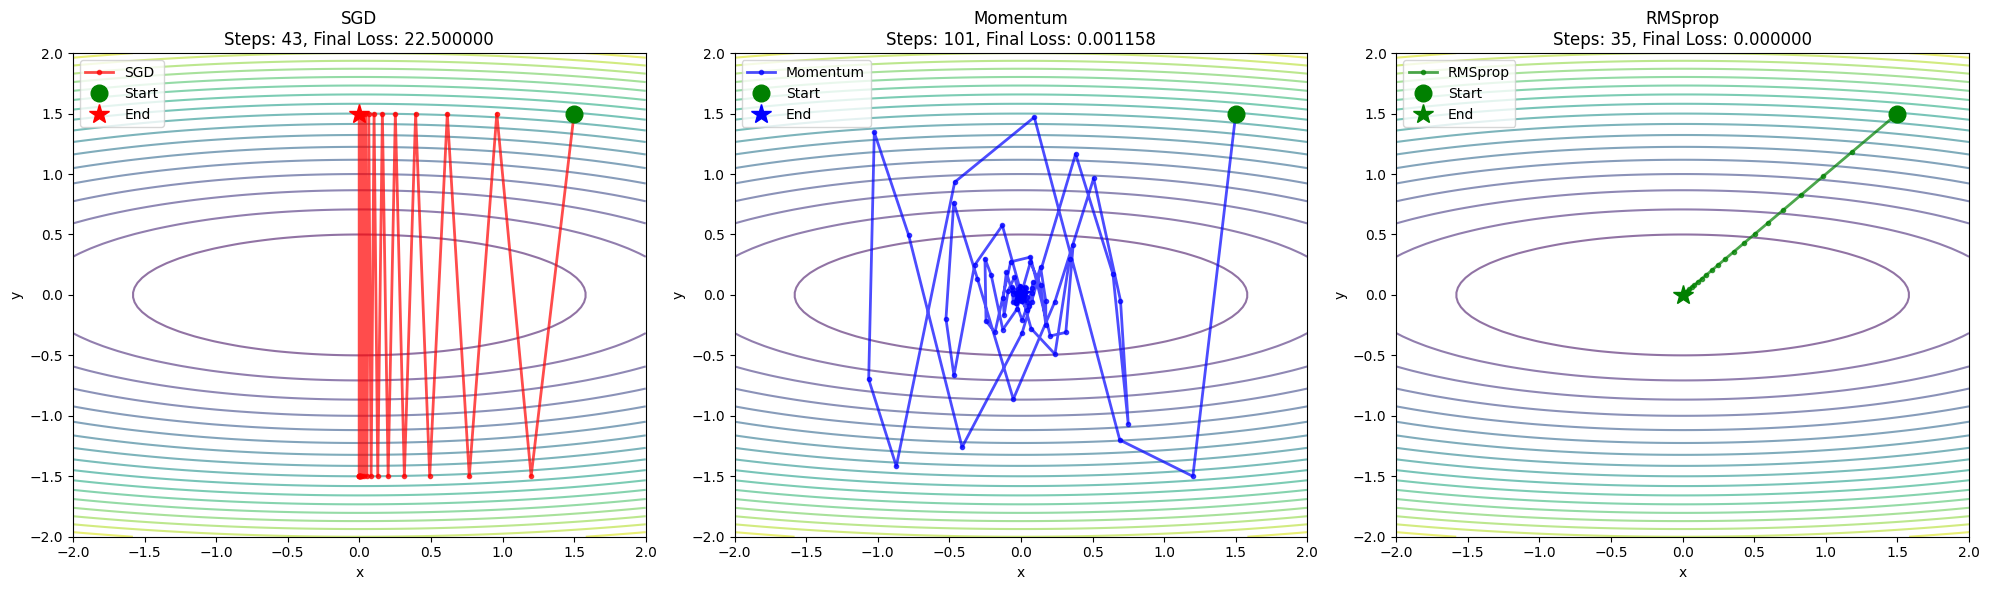

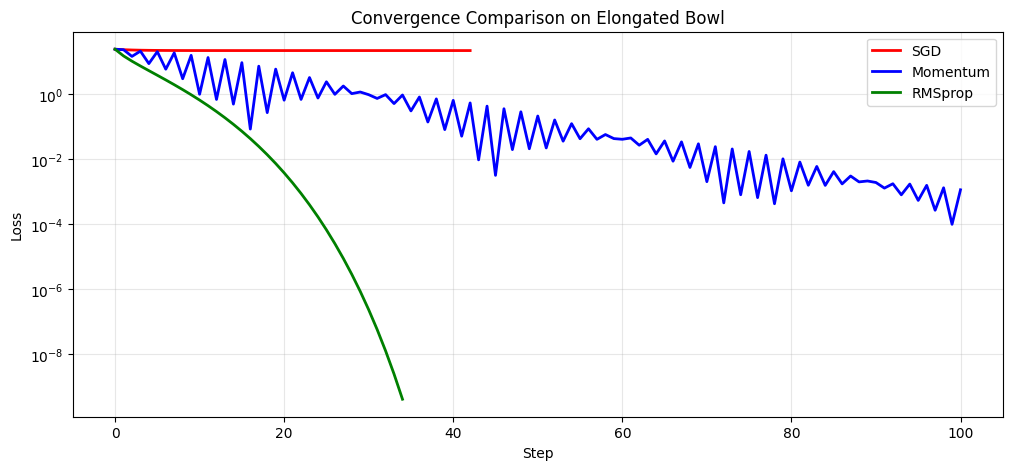

Key Observations:
- SGD: Oscillates, slow convergence
- Momentum: Smoother, but still some oscillation
- RMSprop: Very direct path! Adaptive LR fixes the scale mismatch

✨ RMSprop automatically handles different parameter scales!


In [16]:
# Compare SGD, Momentum, and RMSprop on elongated bowl

start = [1.5, 1.5]

# Run all optimizers
sgd = SGD(lr=0.1)
momentum = Momentum(lr=0.1, beta=0.9)
rmsprop = RMSprop(lr=0.1, beta=0.9)

history_sgd = optimize(elongated_bowl, sgd, start, num_steps=100)
history_momentum = optimize(elongated_bowl, momentum, start, num_steps=100)
history_rmsprop = optimize(elongated_bowl, rmsprop, start, num_steps=100)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, history, title, color in [
    (axes[0], history_sgd, 'SGD', 'red'),
    (axes[1], history_momentum, 'Momentum', 'blue'),
    (axes[2], history_rmsprop, 'RMSprop', 'green')
]:
    x = np.linspace(-2, 2, 100)
    y = np.linspace(-2, 2, 100)
    X, Y = np.meshgrid(x, y)
    Z = elongated_bowl(X, Y)
    
    contour = ax.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
    
    xs = [h[0] for h in history]
    ys = [h[1] for h in history]
    
    ax.plot(xs, ys, '.-', color=color, linewidth=2, markersize=6, alpha=0.7, label=title)
    ax.plot(xs[0], ys[0], 'go', markersize=12, label='Start')
    ax.plot(xs[-1], ys[-1], '*', color=color, markersize=15, label='End')
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{title}\nSteps: {len(history)}, Final Loss: {history[-1][2]:.6f}')
    ax.legend()

plt.tight_layout()
plt.show()

# Loss curves
plot_loss_curves(
    [history_sgd, history_momentum, history_rmsprop],
    ['SGD', 'Momentum', 'RMSprop'],
    title='Convergence Comparison on Elongated Bowl'
)

print("Key Observations:")
print(f"- SGD: Oscillates, slow convergence")
print(f"- Momentum: Smoother, but still some oscillation")
print(f"- RMSprop: Very direct path! Adaptive LR fixes the scale mismatch")
print("\n✨ RMSprop automatically handles different parameter scales!")

Visualize the results with multiple plots for comparison.

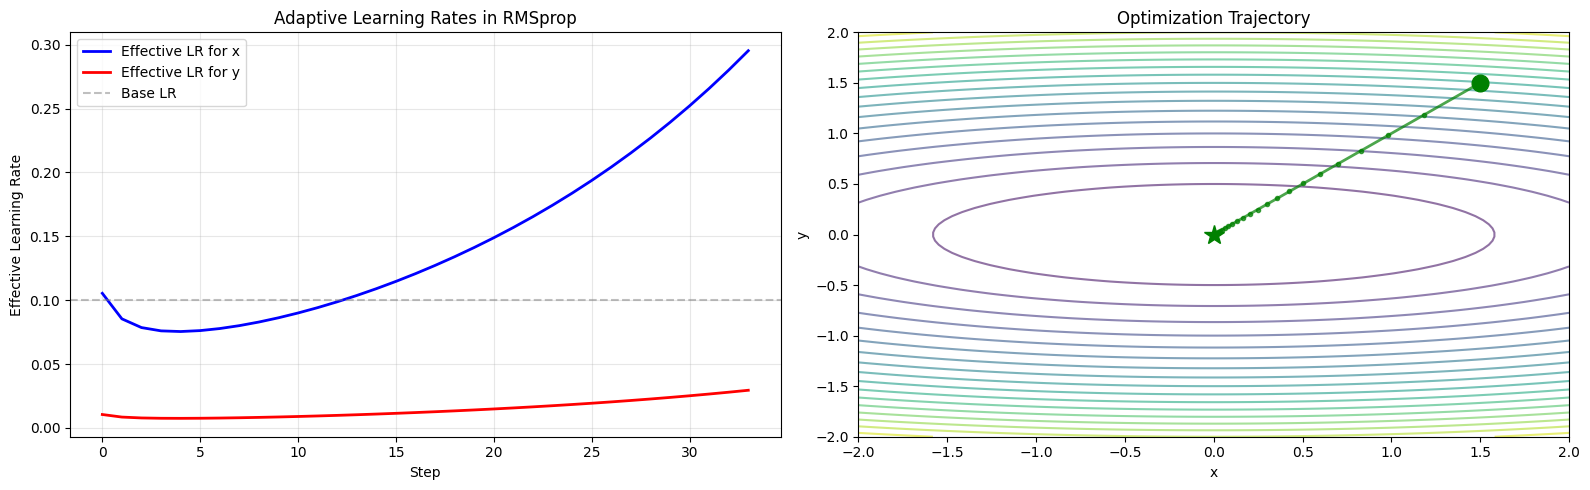

Notice:
- Y-direction has larger gradients (steeper)
- RMSprop automatically reduces effective LR for y
- This balances the updates and eliminates oscillations!


In [17]:
# Visualize how RMSprop adapts learning rates

# Track effective learning rates during optimization
class RMSpropTracker(RMSprop):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.lr_history = []  # Track effective learning rates
    
    def step(self, params, grads):
        if self.s is None:
            self.s = np.zeros_like(grads)
        
        self.s = self.beta * self.s + (1 - self.beta) * grads**2
        
        # Effective learning rate for each dimension
        effective_lr = self.lr / (np.sqrt(self.s) + self.epsilon)
        self.lr_history.append(effective_lr.copy())
        
        adjusted_grad = grads / (np.sqrt(self.s) + self.epsilon)
        return params - self.lr * adjusted_grad

# Run RMSprop with tracking
rmsprop_tracker = RMSpropTracker(lr=0.1, beta=0.9)
history = optimize(elongated_bowl, rmsprop_tracker, [1.5, 1.5], num_steps=50)

# Plot effective learning rates over time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Extract effective LRs
lr_x = [lr[0] for lr in rmsprop_tracker.lr_history]
lr_y = [lr[1] for lr in rmsprop_tracker.lr_history]

ax1.plot(lr_x, label='Effective LR for x', linewidth=2, color='blue')
ax1.plot(lr_y, label='Effective LR for y', linewidth=2, color='red')
ax1.axhline(y=0.1, color='gray', linestyle='--', label='Base LR', alpha=0.5)
ax1.set_xlabel('Step')
ax1.set_ylabel('Effective Learning Rate')
ax1.set_title('Adaptive Learning Rates in RMSprop')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Show the trajectory
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = elongated_bowl(X, Y)

contour = ax2.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)

xs = [h[0] for h in history]
ys = [h[1] for h in history]

ax2.plot(xs, ys, 'g.-', linewidth=2, markersize=6, alpha=0.7)
ax2.plot(xs[0], ys[0], 'go', markersize=12)
ax2.plot(xs[-1], ys[-1], 'g*', markersize=15)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Optimization Trajectory')

plt.tight_layout()
plt.show()

print("Notice:")
print("- Y-direction has larger gradients (steeper)")
print("- RMSprop automatically reduces effective LR for y")
print("- This balances the updates and eliminates oscillations!")

### 🤔 Reflection Questions

1. Why does RMSprop work so well on the elongated bowl?
2. How does RMSprop differ from just using a smaller learning rate?
3. What happens if the gradient is consistently zero for some parameters?

## Part 6: Adam - Combining Momentum and Adaptive Learning Rates

### The Best of Both Worlds

Adam (Adaptive Moment Estimation) combines:
- **Momentum**: Accumulate velocity for consistent directions
- **RMSprop**: Adapt learning rates based on gradient magnitudes

### The Algorithm

$$m_{t+1} = \beta_1 m_t + (1 - \beta_1) \nabla L(\theta_t)$$
$$v_{t+1} = \beta_2 v_t + (1 - \beta_2) (\nabla L(\theta_t))^2$$
$$\hat{m}_{t+1} = \frac{m_{t+1}}{1 - \beta_1^{t+1}}$$
$$\hat{v}_{t+1} = \frac{v_{t+1}}{1 - \beta_2^{t+1}}$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_{t+1}} + \epsilon} \hat{m}_{t+1}$$

Where:
- $m_t$ = first moment (mean) - like momentum
- $v_t$ = second moment (variance) - like RMSprop
- $\beta_1$ = momentum decay (typically 0.9)
- $\beta_2$ = RMSprop decay (typically 0.999)
- $\hat{m}, \hat{v}$ = bias-corrected estimates

**Bias Correction**: The $\hat{m}$ and $\hat{v}$ terms correct for initialization bias (both $m$ and $v$ start at 0).

### Why Adam Works So Well

1. **Momentum** → smooth trajectory, escape plateaus
2. **Adaptive LR** → handle different parameter scales
3. **Bias correction** → works from the first step
4. **Robust** → works well with default hyperparameters

In [18]:
# Implement Adam from scratch

class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        """
        Adam optimizer
        
        Args:
            lr: Learning rate (note: typically lower than SGD)
            beta1: Decay rate for first moment (momentum)
            beta2: Decay rate for second moment (RMSprop)
            epsilon: Small constant for numerical stability
        """
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None  # First moment (momentum)
        self.v = None  # Second moment (RMSprop)
        self.t = 0     # Time step (for bias correction)
    
    def step(self, params, grads):
        """
        Update parameters using Adam
        
        Args:
            params: Current parameters [x, y]
            grads: Gradients [dx, dy]
        
        Returns:
            Updated parameters
        """
        # Initialize on first step
        if self.m is None:
            self.m = np.zeros_like(grads)
            self.v = np.zeros_like(grads)
        
        self.t += 1
        
        # Update biased first moment (momentum)
        self.m = self.beta1 * self.m + (1 - self.beta1) * grads
        
        # Update biased second moment (RMSprop)
        self.v = self.beta2 * self.v + (1 - self.beta2) * grads**2
        
        # Bias correction
        m_hat = self.m / (1 - self.beta1**self.t)
        v_hat = self.v / (1 - self.beta2**self.t)
        
        # Update parameters
        return params - self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

print("✓ Adam implementation complete")
print(f"\nAlgorithm:")
print(f"  m = β₁*m + (1-β₁)*∇L          [momentum]")
print(f"  v = β₂*v + (1-β₂)*∇L²         [RMSprop]")
print(f"  m̂ = m / (1-β₁ᵗ)               [bias correction]")
print(f"  v̂ = v / (1-β₂ᵗ)               [bias correction]")
print(f"  θ_new = θ - η * m̂ / (√v̂ + ε)  [update]")
print(f"\nMemory: O(2n) - stores both momentum and squared gradients")
print(f"Default hyperparameters work well for most problems!")

✓ Adam implementation complete

Algorithm:
  m = β₁*m + (1-β₁)*∇L          [momentum]
  v = β₂*v + (1-β₂)*∇L²         [RMSprop]
  m̂ = m / (1-β₁ᵗ)               [bias correction]
  v̂ = v / (1-β₂ᵗ)               [bias correction]
  θ_new = θ - η * m̂ / (√v̂ + ε)  [update]

Memory: O(2n) - stores both momentum and squared gradients
Default hyperparameters work well for most problems!


Visualize the results with multiple plots for comparison.

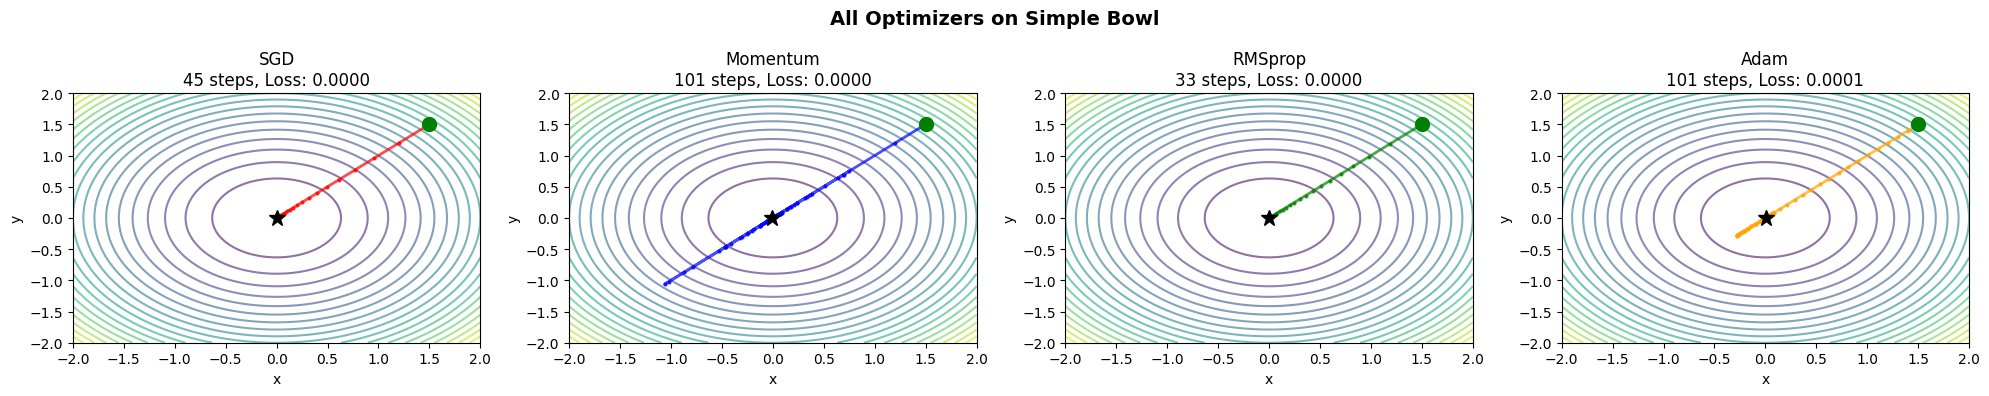

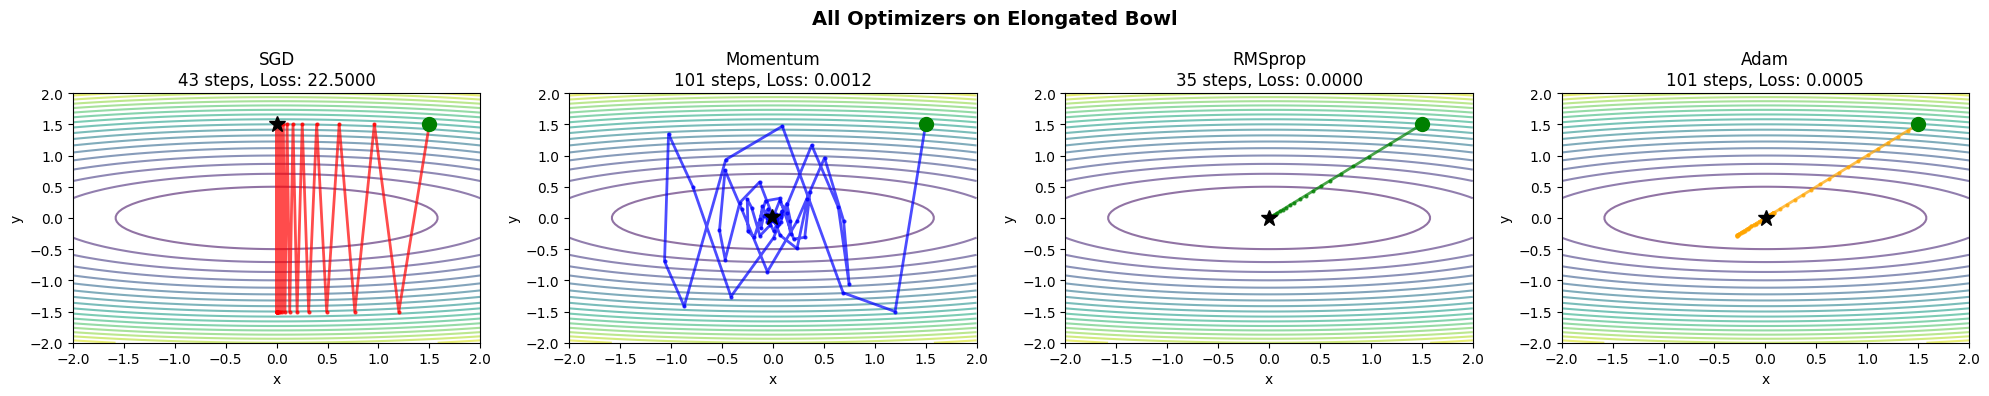

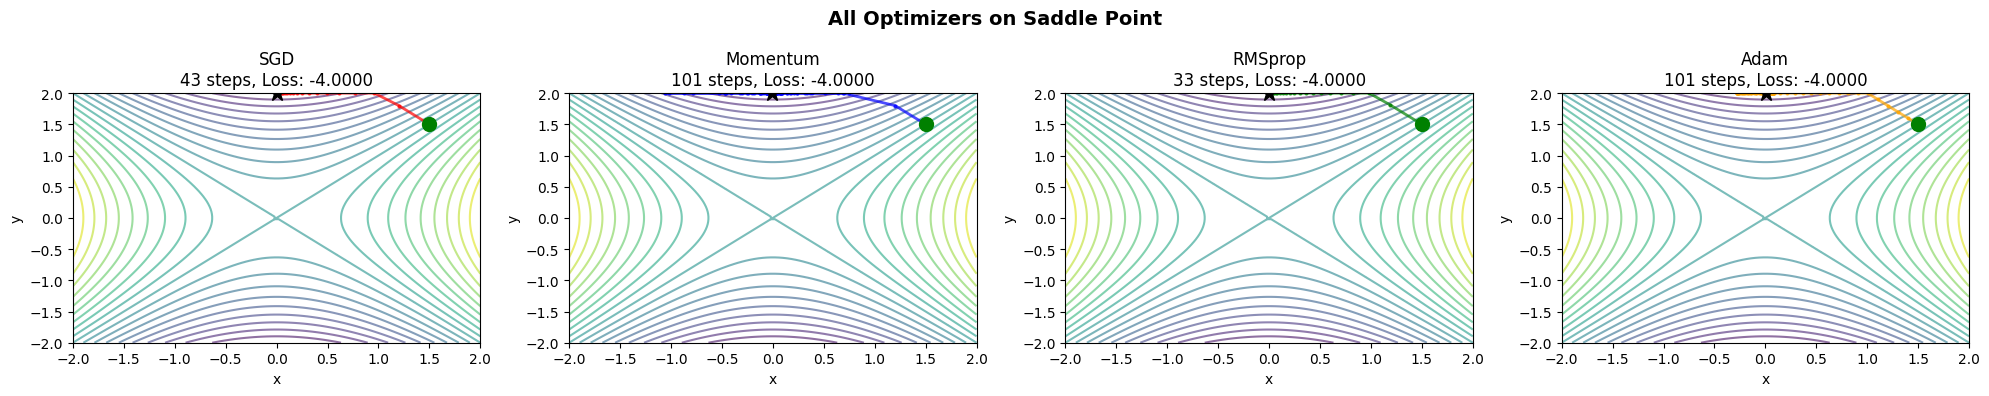


✨ Summary of Optimizer Behaviors:
- SGD: Simple, but oscillates on anisotropic surfaces
- Momentum: Smooth, accelerates in consistent directions
- RMSprop: Handles scale differences well, adapts per-parameter
- Adam: Best of both worlds, robust across different landscapes


In [19]:
# Compare all four optimizers on multiple landscapes

landscapes = [
    (simple_quadratic, (-2, 2), (-2, 2), "Simple Bowl"),
    (elongated_bowl, (-2, 2), (-2, 2), "Elongated Bowl"),
    (saddle_point, (-2, 2), (-2, 2), "Saddle Point"),
]

optimizers = [
    (SGD(lr=0.1), 'SGD', 'red'),
    (Momentum(lr=0.1, beta=0.9), 'Momentum', 'blue'),
    (RMSprop(lr=0.1, beta=0.9), 'RMSprop', 'green'),
    (Adam(lr=0.1, beta1=0.9, beta2=0.999), 'Adam', 'orange'),
]

for func, x_range, y_range, landscape_name in landscapes:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'All Optimizers on {landscape_name}', fontsize=14, fontweight='bold')
    
    start = [1.5, 1.5]
    
    for ax, (opt, name, color) in zip(axes, optimizers):
        # Reset optimizer state
        if hasattr(opt, 'v'):
            opt.v = None
        if hasattr(opt, 's'):
            opt.s = None
        if hasattr(opt, 'm'):
            opt.m = None
            opt.t = 0
        
        history = optimize(func, opt, start, num_steps=100, x_range=x_range, y_range=y_range)
        
        # Plot
        x = np.linspace(*x_range, 100)
        y = np.linspace(*y_range, 100)
        X, Y = np.meshgrid(x, y)
        Z = func(X, Y)
        
        contour = ax.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
        
        xs = [h[0] for h in history]
        ys = [h[1] for h in history]
        
        ax.plot(xs, ys, '.-', color=color, linewidth=2, markersize=4, alpha=0.7)
        ax.plot(xs[0], ys[0], 'go', markersize=10)
        ax.plot(xs[-1], ys[-1], 'k*', markersize=12)
        
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(f'{name}\n{len(history)} steps, Loss: {history[-1][2]:.4f}')
    
    plt.tight_layout()
    plt.show()

print("\n✨ Summary of Optimizer Behaviors:")
print("- SGD: Simple, but oscillates on anisotropic surfaces")
print("- Momentum: Smooth, accelerates in consistent directions")
print("- RMSprop: Handles scale differences well, adapts per-parameter")
print("- Adam: Best of both worlds, robust across different landscapes")

### Understanding Bias Correction

Why do we need bias correction in Adam?

Both $m$ and $v$ are initialized to 0, so in early iterations they're biased toward zero. The bias correction terms $\frac{1}{1-\beta^t}$ amplify the estimates to compensate.

Let's visualize this:

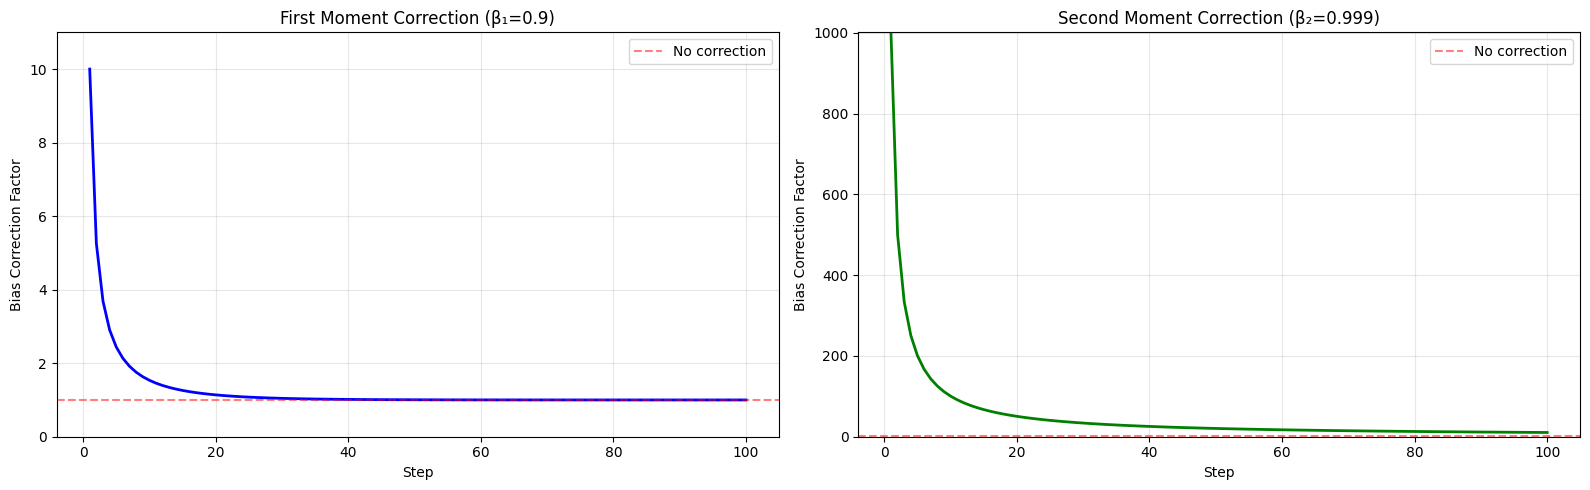

Key insights:
- Correction factor starts high (amplifies early estimates)
- Quickly approaches 1 (no correction needed after warmup)
- β₂ is closer to 1, so correction is more aggressive initially

Without correction: early steps would have tiny, biased updates!


In [20]:
# Visualize bias correction effect

beta1, beta2 = 0.9, 0.999
steps = np.arange(1, 101)

# Bias correction factors
correction1 = 1 / (1 - beta1**steps)
correction2 = 1 / (1 - beta2**steps)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# First moment
axes[0].plot(steps, correction1, linewidth=2, color='blue')
axes[0].axhline(y=1, color='red', linestyle='--', label='No correction', alpha=0.5)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Bias Correction Factor')
axes[0].set_title(f'First Moment Correction (β₁={beta1})')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_ylim([0, 11])

# Second moment
axes[1].plot(steps, correction2, linewidth=2, color='green')
axes[1].axhline(y=1, color='red', linestyle='--', label='No correction', alpha=0.5)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Bias Correction Factor')
axes[1].set_title(f'Second Moment Correction (β₂={beta2})')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_ylim([0, 1001])

plt.tight_layout()
plt.show()

print("Key insights:")
print(f"- Correction factor starts high (amplifies early estimates)")
print(f"- Quickly approaches 1 (no correction needed after warmup)")
print(f"- β₂ is closer to 1, so correction is more aggressive initially")
print(f"\nWithout correction: early steps would have tiny, biased updates!")

## Part 7: Head-to-Head Comparison on Challenging Landscapes

Let's test all optimizers on the most challenging landscapes: Beale and Rosenbrock functions.

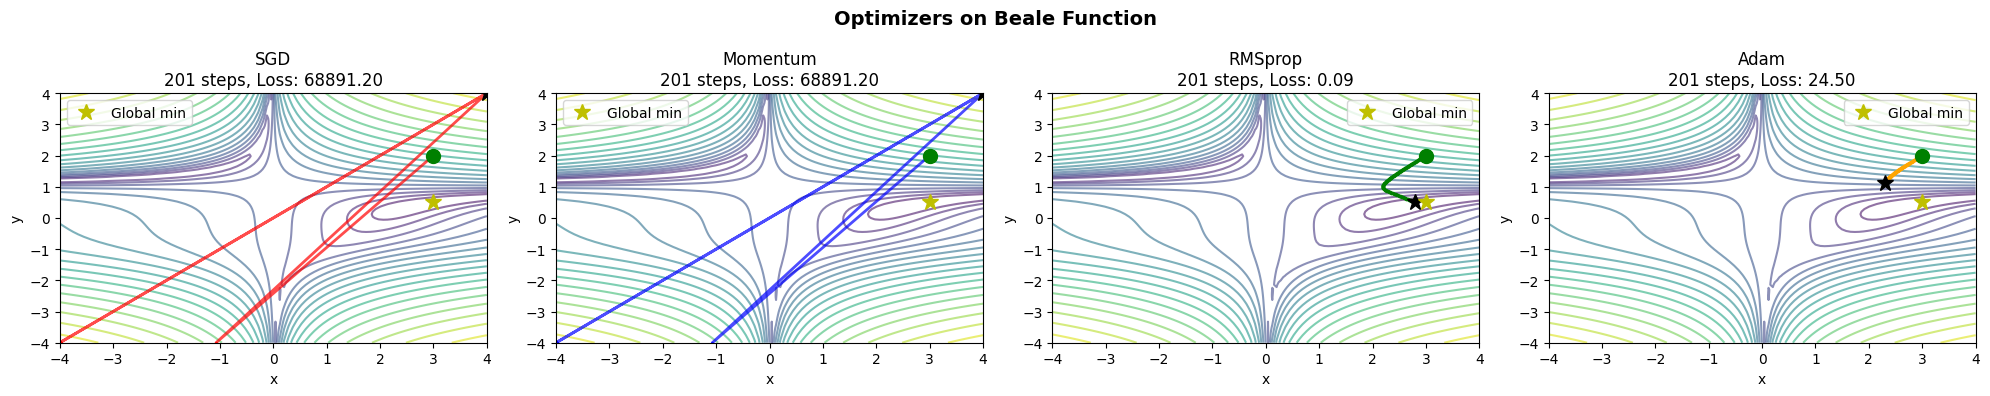

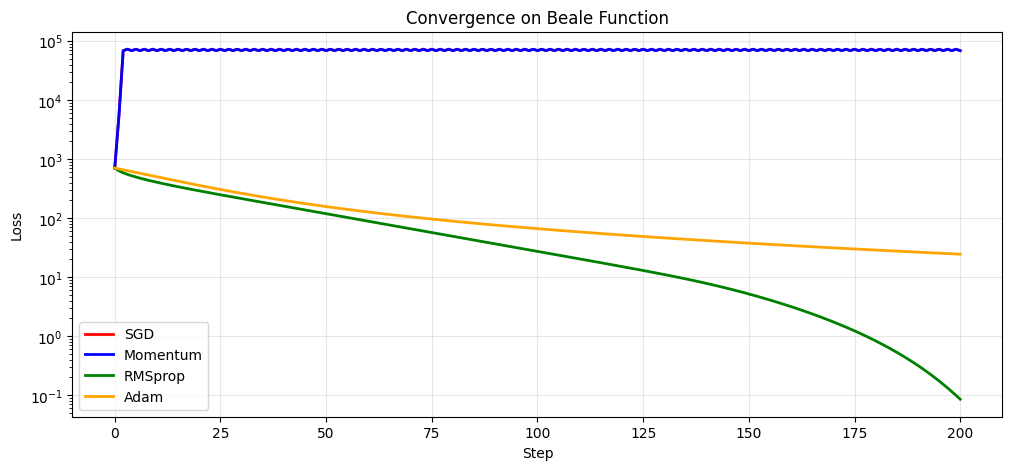

In [21]:
# Test on Beale function

start_beale = [3.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Optimizers on Beale Function', fontsize=14, fontweight='bold')

optimizers = [
    (SGD(lr=0.01), 'SGD', 'red'),
    (Momentum(lr=0.01, beta=0.9), 'Momentum', 'blue'),
    (RMSprop(lr=0.01, beta=0.9), 'RMSprop', 'green'),
    (Adam(lr=0.01), 'Adam', 'orange'),
]

histories_beale = []

for ax, (opt, name, color) in zip(axes, optimizers):
    # Reset optimizer
    if hasattr(opt, 'v'):
        opt.v = None
    if hasattr(opt, 's'):
        opt.s = None
    if hasattr(opt, 'm'):
        opt.m = None
        opt.t = 0
    
    history = optimize(beale, opt, start_beale, num_steps=200, x_range=(-4, 4), y_range=(-4, 4))
    histories_beale.append(history)
    
    # Plot
    x = np.linspace(-4, 4, 100)
    y = np.linspace(-4, 4, 100)
    X, Y = np.meshgrid(x, y)
    Z = beale(X, Y)
    
    contour = ax.contour(X, Y, np.log(Z + 1), levels=20, cmap='viridis', alpha=0.6)
    
    xs = [h[0] for h in history]
    ys = [h[1] for h in history]
    
    ax.plot(xs, ys, '.-', color=color, linewidth=2, markersize=3, alpha=0.7)
    ax.plot(xs[0], ys[0], 'go', markersize=10)
    ax.plot(xs[-1], ys[-1], 'k*', markersize=12)
    ax.plot(3, 0.5, 'y*', markersize=12, label='Global min')  # True minimum
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{name}\n{len(history)} steps, Loss: {history[-1][2]:.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

# Loss curves
plot_loss_curves(
    histories_beale,
    ['SGD', 'Momentum', 'RMSprop', 'Adam'],
    title='Convergence on Beale Function'
)

Visualize the results with multiple plots for comparison.

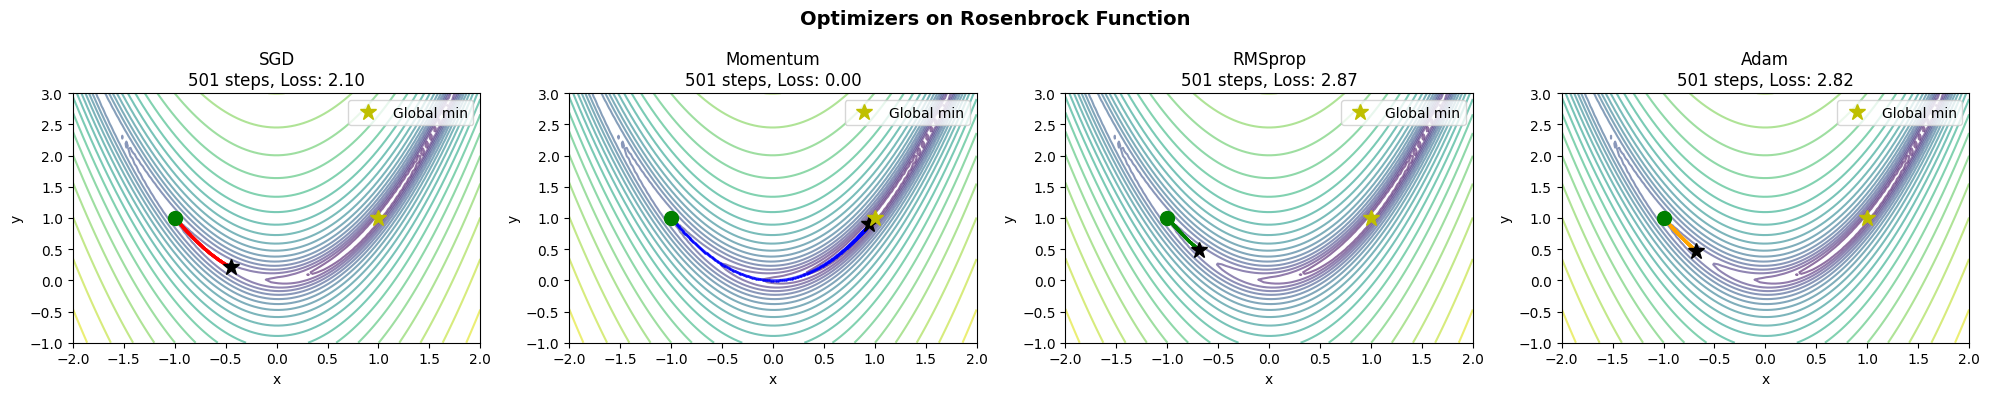

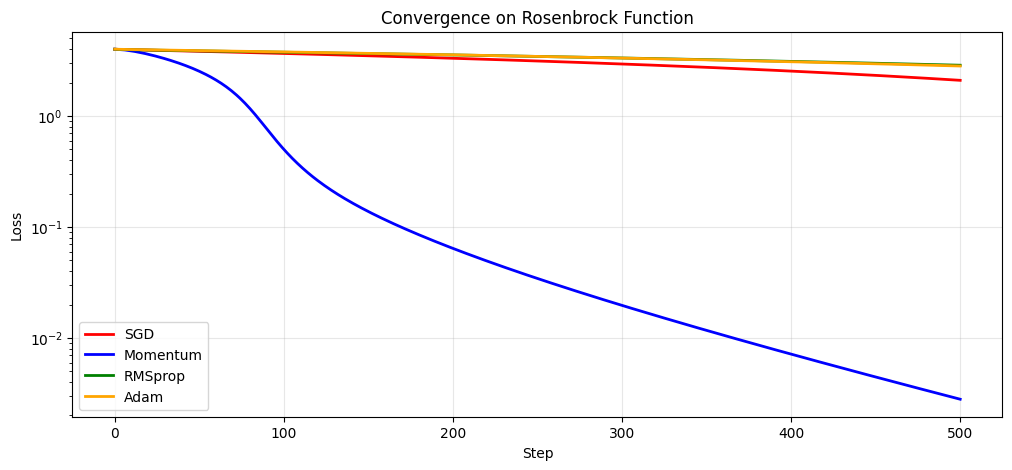


Rosenbrock is notorious for its narrow banana-shaped valley!


In [22]:
# Test on Rosenbrock function

start_rosen = [-1.0, 1.0]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Optimizers on Rosenbrock Function', fontsize=14, fontweight='bold')

optimizers = [
    (SGD(lr=0.001), 'SGD', 'red'),
    (Momentum(lr=0.001, beta=0.9), 'Momentum', 'blue'),
    (RMSprop(lr=0.001, beta=0.9), 'RMSprop', 'green'),
    (Adam(lr=0.001), 'Adam', 'orange'),
]

histories_rosen = []

for ax, (opt, name, color) in zip(axes, optimizers):
    # Reset optimizer
    if hasattr(opt, 'v'):
        opt.v = None
    if hasattr(opt, 's'):
        opt.s = None
    if hasattr(opt, 'm'):
        opt.m = None
        opt.t = 0
    
    history = optimize(rosenbrock, opt, start_rosen, num_steps=500, x_range=(-2, 2), y_range=(-1, 3))
    histories_rosen.append(history)
    
    # Plot
    x = np.linspace(-2, 2, 100)
    y = np.linspace(-1, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = rosenbrock(X, Y)
    
    contour = ax.contour(X, Y, np.log(Z + 1), levels=20, cmap='viridis', alpha=0.6)
    
    xs = [h[0] for h in history]
    ys = [h[1] for h in history]
    
    ax.plot(xs, ys, '.-', color=color, linewidth=2, markersize=2, alpha=0.7)
    ax.plot(xs[0], ys[0], 'go', markersize=10)
    ax.plot(xs[-1], ys[-1], 'k*', markersize=12)
    ax.plot(1, 1, 'y*', markersize=12, label='Global min')  # True minimum
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{name}\n{len(history)} steps, Loss: {history[-1][2]:.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

# Loss curves
plot_loss_curves(
    histories_rosen,
    ['SGD', 'Momentum', 'RMSprop', 'Adam'],
    title='Convergence on Rosenbrock Function'
)

print("\nRosenbrock is notorious for its narrow banana-shaped valley!")

### 🤔 Reflection Questions

1. Why do adaptive methods (RMSprop, Adam) generally perform better on complex landscapes?
2. Are there cases where simpler methods might be preferable?
3. How sensitive is each optimizer to its hyperparameters?

## Part 8: Real Neural Network Training

Now let's see how these optimizers perform on actual neural network training!

We'll train a simple feedforward network on a synthetic classification task.

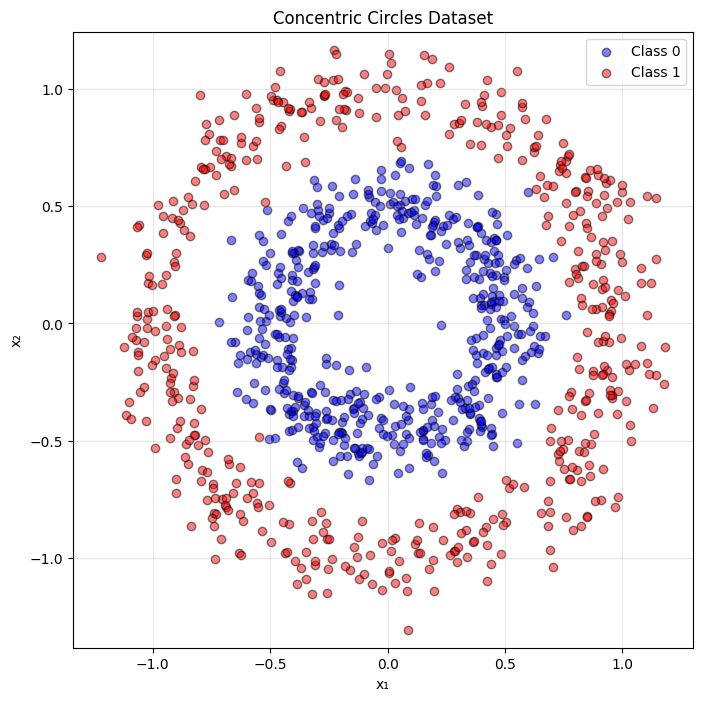

Training samples: 1000
Test samples: 200


In [23]:
# Create a synthetic dataset (concentric circles)

def make_circles(n_samples=1000, noise=0.1):
    """
    Generate a binary classification dataset with two concentric circles
    """
    np.random.seed(42)
    
    # Outer circle
    theta = np.random.uniform(0, 2*np.pi, n_samples//2)
    r = 1.0 + np.random.normal(0, noise, n_samples//2)
    X_outer = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
    y_outer = np.ones(n_samples//2)
    
    # Inner circle
    theta = np.random.uniform(0, 2*np.pi, n_samples//2)
    r = 0.5 + np.random.normal(0, noise, n_samples//2)
    X_inner = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
    y_inner = np.zeros(n_samples//2)
    
    # Combine
    X = np.vstack([X_outer, X_inner]).astype(np.float32)
    y = np.concatenate([y_outer, y_inner]).astype(np.int64)
    
    # Shuffle
    idx = np.random.permutation(n_samples)
    X, y = X[idx], y[idx]
    
    return X, y

# Generate data
X_train, y_train = make_circles(n_samples=1000, noise=0.1)
X_test, y_test = make_circles(n_samples=200, noise=0.1)

# Visualize
plt.figure(figsize=(8, 8))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
            c='blue', label='Class 0', alpha=0.5, edgecolors='k')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
            c='red', label='Class 1', alpha=0.5, edgecolors='k')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Concentric Circles Dataset')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Define the SimpleNN architecture.

In [24]:
# Define a simple neural network

class SimpleNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print("✓ Neural network defined")
print("\nArchitecture: 2 → 32 → 32 → 2")
print("Activation: ReLU")
print("Output: Logits (for cross-entropy loss)")

✓ Neural network defined

Architecture: 2 → 32 → 32 → 2
Activation: ReLU
Output: Logits (for cross-entropy loss)


Train the model and monitor progress.

In [25]:
# Training function

def train_model(model, optimizer, X_train, y_train, X_test, y_test, epochs=100, batch_size=32):
    """
    Train a model and track metrics
    
    Returns:
        history: Dict with train_loss, train_acc, test_loss, test_acc lists
    """
    # Convert to tensors
    X_train_t = torch.from_numpy(X_train).to(device)
    y_train_t = torch.from_numpy(y_train).to(device)
    X_test_t = torch.from_numpy(X_test).to(device)
    y_test_t = torch.from_numpy(y_test).to(device)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        # Training
        model.train()
        
        # Mini-batch training
        indices = torch.randperm(len(X_train_t))
        for i in range(0, len(X_train_t), batch_size):
            batch_idx = indices[i:i+batch_size]
            X_batch = X_train_t[batch_idx]
            y_batch = y_train_t[batch_idx]
            
            # Forward
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        # Evaluation
        model.eval()
        with torch.no_grad():
            # Train metrics
            train_outputs = model(X_train_t)
            train_loss = criterion(train_outputs, y_train_t).item()
            train_acc = (train_outputs.argmax(1) == y_train_t).float().mean().item()
            
            # Test metrics
            test_outputs = model(X_test_t)
            test_loss = criterion(test_outputs, y_test_t).item()
            test_acc = (test_outputs.argmax(1) == y_test_t).float().mean().item()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                  f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    return history

print("✓ Training function ready")

✓ Training function ready


Train the model and monitor progress.

In [26]:
# Train with all optimizers

set_seed(42)

optimizers_config = [
    ('SGD', torch.optim.SGD, {'lr': 0.1}),
    ('Momentum', torch.optim.SGD, {'lr': 0.1, 'momentum': 0.9}),
    ('RMSprop', torch.optim.RMSprop, {'lr': 0.01, 'alpha': 0.9}),
    ('Adam', torch.optim.Adam, {'lr': 0.01}),
]

histories = {}
trained_models = {}

for name, opt_class, opt_kwargs in optimizers_config:
    print(f"\n{'='*60}")
    print(f"Training with {name}")
    print(f"{'='*60}")
    
    # Create fresh model
    set_seed(42)  # Same initialization for fair comparison
    model = SimpleNN().to(device)
    
    # Create optimizer
    optimizer = opt_class(model.parameters(), **opt_kwargs)
    
    # Train
    history = train_model(model, optimizer, X_train, y_train, X_test, y_test, 
                         epochs=100, batch_size=32)
    
    histories[name] = history
    trained_models[name] = model

print("\n" + "="*60)
print("Training complete!")
print("="*60)


Training with SGD


Epoch 20/100 - Train Loss: 0.0332, Train Acc: 0.9930, Test Loss: 0.0259, Test Acc: 1.0000


Epoch 40/100 - Train Loss: 0.0202, Train Acc: 0.9930, Test Loss: 0.0127, Test Acc: 1.0000


Epoch 60/100 - Train Loss: 0.0147, Train Acc: 0.9940, Test Loss: 0.0069, Test Acc: 1.0000


Epoch 80/100 - Train Loss: 0.0098, Train Acc: 0.9960, Test Loss: 0.0042, Test Acc: 1.0000


...

Epoch 20/100 - Train Loss: 0.0186, Train Acc: 0.9920, Test Loss: 0.0171, Test Acc: 0.9950


Epoch 40/100 - Train Loss: 0.0148, Train Acc: 0.9940, Test Loss: 0.0027, Test Acc: 1.0000


Epoch 60/100 - Train Loss: 0.0218, Train Acc: 0.9920, Test Loss: 0.0089, Test Acc: 0.9950


Epoch 80/100 - Train Loss: 0.0255, Train Acc: 0.9890, Test Loss: 0.0182, Test Acc: 0.9900


Epoch 100/100 - Train Loss: 0.0263, Train Acc: 0.9910, Test Loss: 0.0086, Test Acc: 0.9950

Training complete!


Visualize the results with multiple plots for comparison.

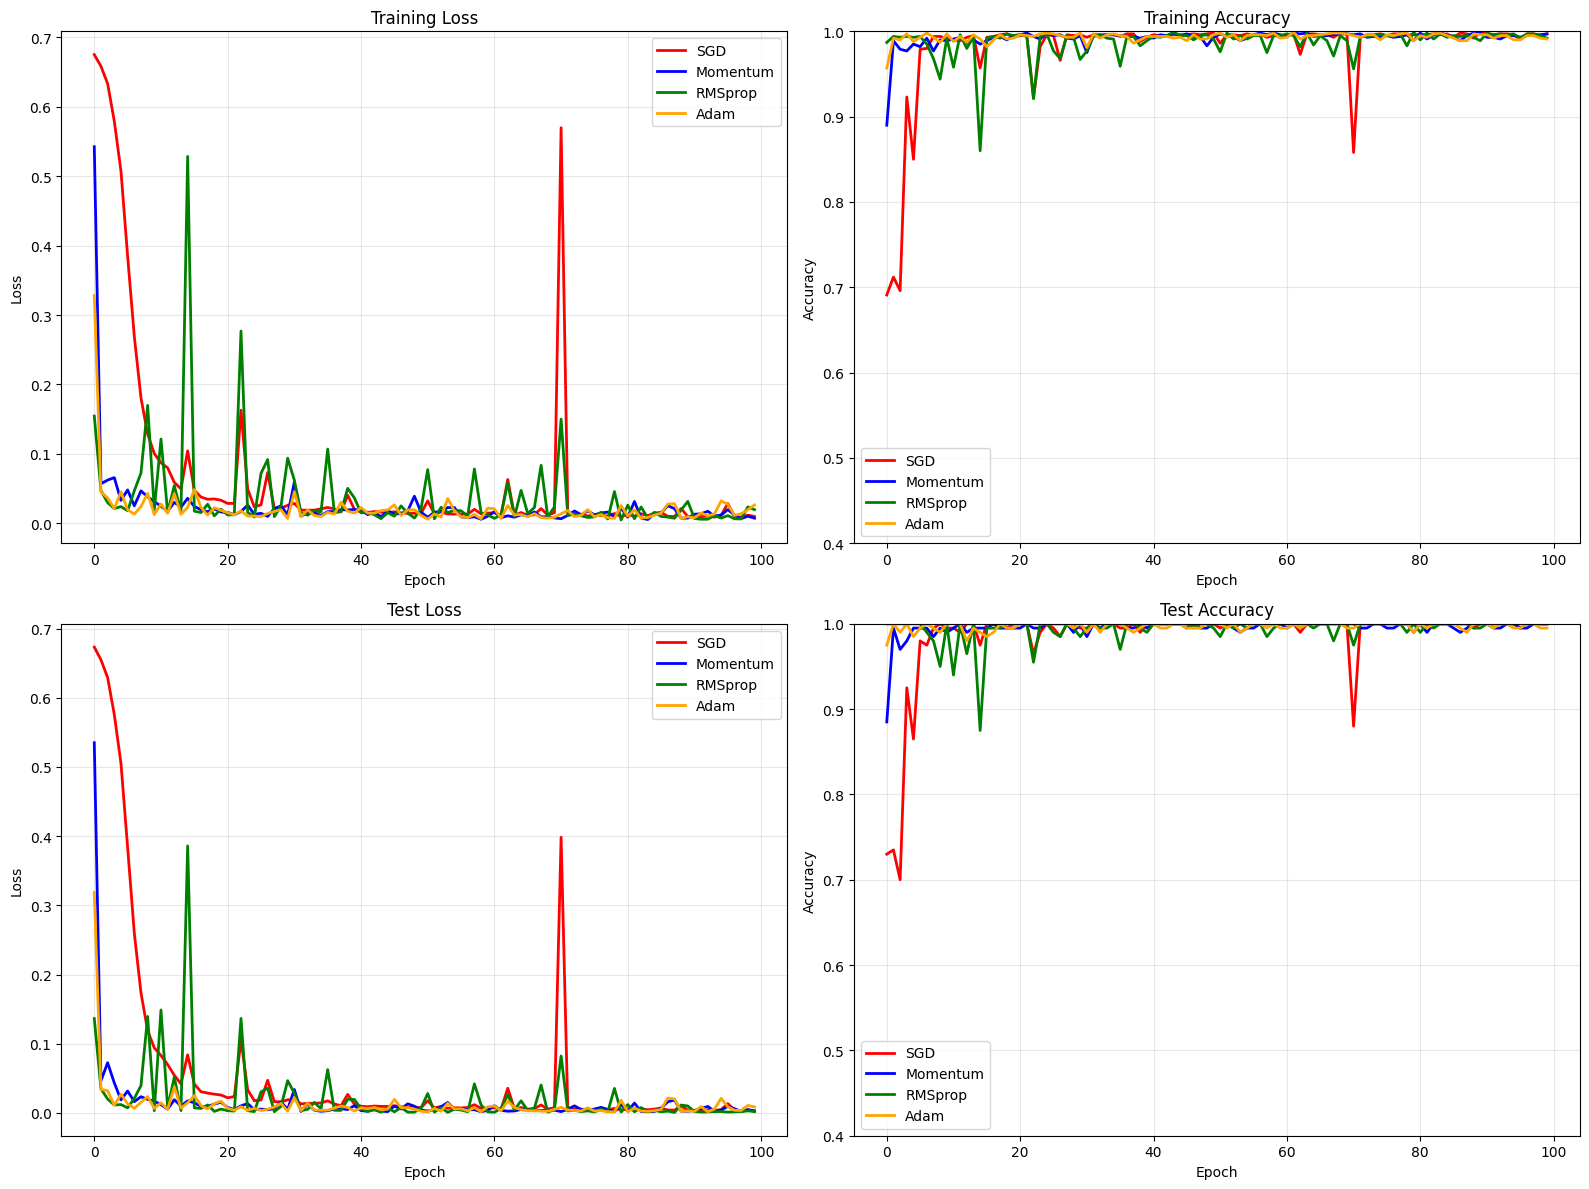


Final Test Accuracy:
  SGD         : 1.0000
  Momentum    : 1.0000
  RMSprop     : 1.0000
  Adam        : 0.9950


In [27]:
# Plot training curves

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = ['red', 'blue', 'green', 'orange']
names = ['SGD', 'Momentum', 'RMSprop', 'Adam']

# Train loss
ax = axes[0, 0]
for name, color in zip(names, colors):
    ax.plot(histories[name]['train_loss'], label=name, color=color, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Train accuracy
ax = axes[0, 1]
for name, color in zip(names, colors):
    ax.plot(histories[name]['train_acc'], label=name, color=color, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.4, 1.0])

# Test loss
ax = axes[1, 0]
for name, color in zip(names, colors):
    ax.plot(histories[name]['test_loss'], label=name, color=color, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Test Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Test accuracy
ax = axes[1, 1]
for name, color in zip(names, colors):
    ax.plot(histories[name]['test_acc'], label=name, color=color, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Test Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.4, 1.0])

plt.tight_layout()
plt.show()

# Final metrics
print("\nFinal Test Accuracy:")
for name in names:
    final_acc = histories[name]['test_acc'][-1]
    print(f"  {name:12s}: {final_acc:.4f}")

Visualize the results with multiple plots for comparison.

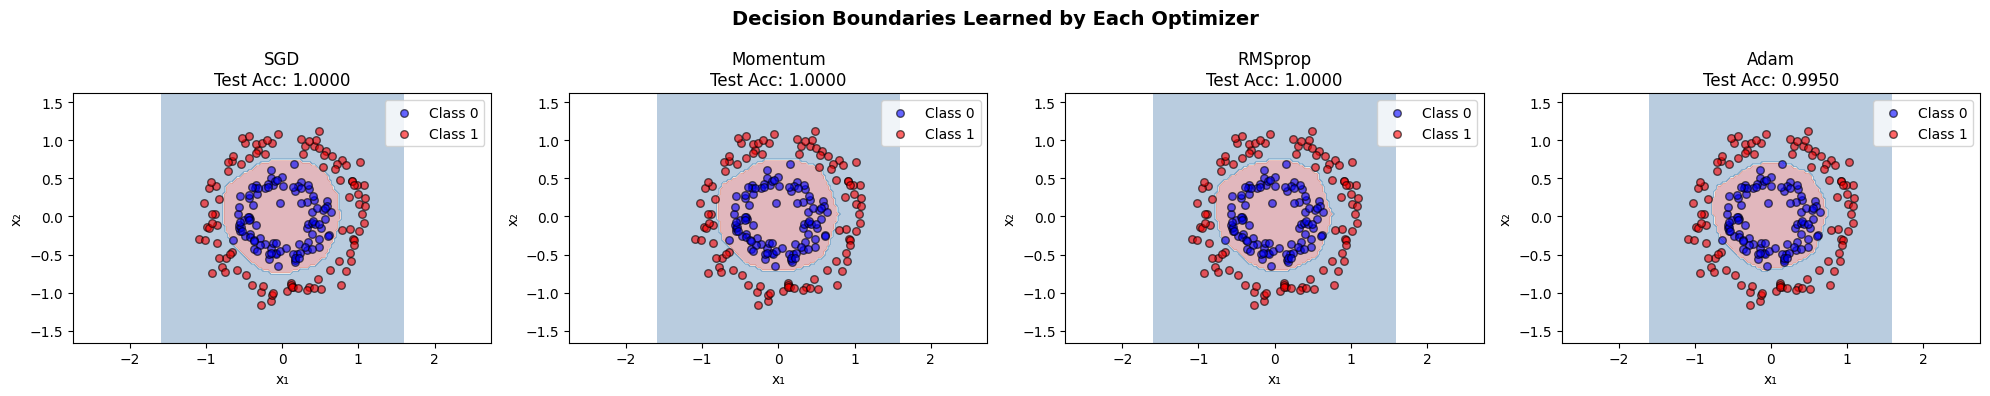

In [28]:
# Visualize decision boundaries

def plot_decision_boundary(model, X, y, title="", resolution=100):
    """
    Plot decision boundary of a model
    """
    # Create mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                         np.linspace(y_min, y_max, resolution))
    
    # Predict
    X_mesh = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    X_mesh_t = torch.from_numpy(X_mesh).to(device)
    
    model.eval()
    with torch.no_grad():
        Z = model(X_mesh_t).argmax(1).cpu().numpy()
    
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Class 0', 
                alpha=0.6, edgecolors='k', s=30)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Class 1', 
                alpha=0.6, edgecolors='k', s=30)
    plt.xlabel('x₁')
    plt.ylabel('x₂')
    plt.title(title)
    plt.legend()
    plt.axis('equal')

# Plot decision boundaries for all optimizers
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Decision Boundaries Learned by Each Optimizer', fontsize=14, fontweight='bold')

for ax, name in zip(axes, names):
    plt.sca(ax)
    model = trained_models[name]
    final_acc = histories[name]['test_acc'][-1]
    plot_decision_boundary(model, X_test, y_test, 
                          title=f'{name}\nTest Acc: {final_acc:.4f}')

plt.tight_layout()
plt.show()

## Part 9: Summary and Practical Guidance

### When to Use Each Optimizer

| Optimizer | Use When | Pros | Cons |
|-----------|----------|------|------|
| **SGD** | Simple problems, when you need reproducibility | Simple, reliable, low memory | Slow on complex landscapes, sensitive to LR |
| **Momentum** | When gradients are noisy or have ravines | Faster convergence, smoother trajectory | One more hyperparameter (β) |
| **RMSprop** | RNNs, non-stationary objectives, sparse gradients | Adapts per-parameter, handles scale differences | Can be aggressive early on |
| **Adam** | Default choice for most deep learning tasks | Robust, works out-of-the-box, fast convergence | Higher memory, may overshoot sometimes |

### Hyperparameter Recommendations

**SGD**
- Learning rate: 0.01 - 0.1 (problem-dependent)
- Use learning rate scheduling!

**Momentum**
- Learning rate: 0.01 - 0.1
- β (momentum): 0.9 (standard), 0.99 (high momentum)

**RMSprop**
- Learning rate: 0.001 - 0.01
- β (decay): 0.9 (standard), 0.99 (more stable)
- ε: 1e-8 (default is fine)

**Adam**
- Learning rate: 0.001 (default works well!)
- β₁: 0.9 (momentum, rarely changed)
- β₂: 0.999 (RMSprop, rarely changed)
- ε: 1e-8 (default is fine)

### General Tips

1. **Start with Adam** - It's a safe default that works well across many problems
2. **Use learning rate scheduling** - Decay learning rate over time for better final performance
3. **Try SGD with momentum** - Sometimes simpler is better, especially with good LR scheduling
4. **Batch size matters** - Larger batches allow larger learning rates
5. **Gradient clipping** - Combine with any optimizer to prevent exploding gradients
6. **Weight decay** - Add regularization (often called "AdamW" for Adam with weight decay)

### Modern Variants

The field continues to evolve:
- **AdamW**: Adam with decoupled weight decay (better regularization)
- **RAdam**: Rectified Adam (more stable early training)
- **Lookahead**: Wrapper that maintains fast and slow weights
- **LAMB**: Layer-wise adaptive moments (for very large batch training)

But the core principles from SGD, Momentum, RMSprop, and Adam remain fundamental!

## Part 10: Final Experiments

### 🧪 Experiment Ideas

Try modifying the code above to explore:

1. **Learning Rate Sensitivity**
   - How does each optimizer respond to 10x larger/smaller learning rates?
   - Which optimizer is most robust?

2. **Batch Size Effects**
   - Train with batch sizes: 1, 16, 64, 256
   - How does this affect convergence speed and stability?

3. **Learning Rate Schedules**
   - Add `torch.optim.lr_scheduler.StepLR` or `CosineAnnealingLR`
   - Does this help SGD catch up to Adam?

4. **Different Architectures**
   - Deeper networks (4-5 layers)
   - Different activation functions (Tanh, LeakyReLU)
   - Batch normalization or dropout

5. **Real Datasets**
   - Try on MNIST or CIFAR-10
   - Do the relative performance differences hold?

### Example: Learning Rate Schedule

Training SGD with learning rate scheduling...



Epoch 20/100 - Loss: 0.0332, Test Acc: 1.0000, LR: 0.100000


Epoch 40/100 - Loss: 0.0177, Test Acc: 1.0000, LR: 0.050000


Epoch 60/100 - Loss: 0.0155, Test Acc: 1.0000, LR: 0.025000


Epoch 80/100 - Loss: 0.0133, Test Acc: 1.0000, LR: 0.025000


Epoch 100/100 - Loss: 0.0126, Test Acc: 1.0000, LR: 0.012500


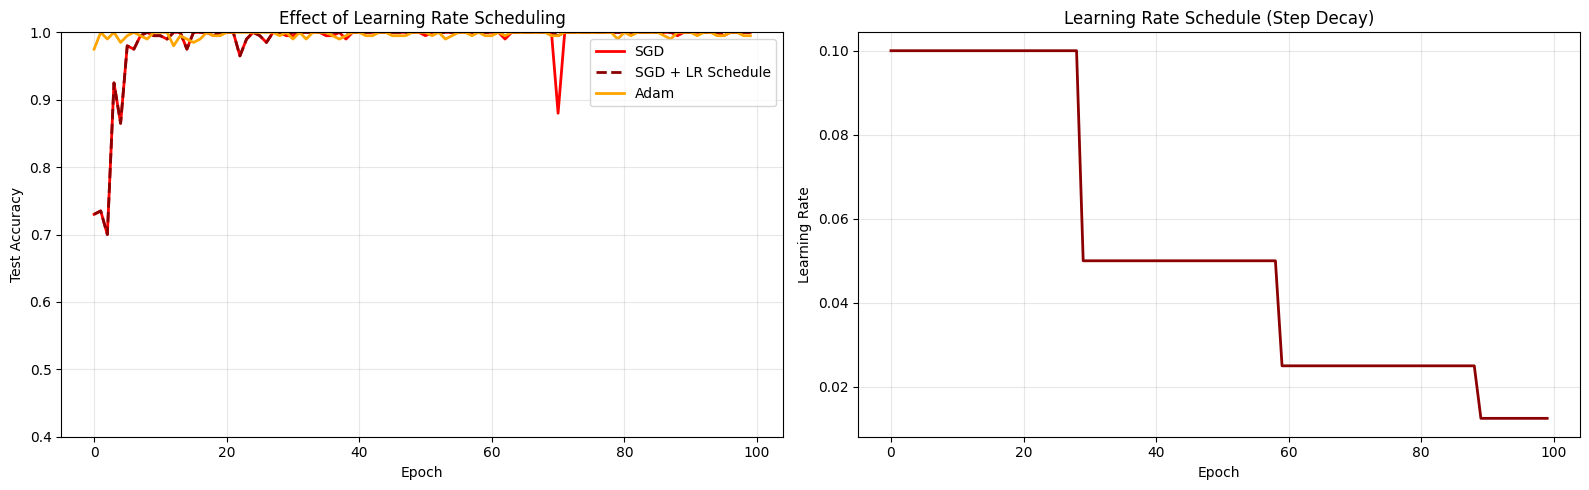


Final test accuracy:
  SGD (no schedule): 1.0000
  SGD (with schedule): 1.0000
  Adam: 0.9950

✨ Learning rate scheduling helps SGD significantly!


In [29]:
# Example: Add learning rate scheduling to SGD

set_seed(42)
model_sgd_sched = SimpleNN().to(device)
optimizer_sgd = torch.optim.SGD(model_sgd_sched.parameters(), lr=0.1)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_sgd, step_size=30, gamma=0.5)

print("Training SGD with learning rate scheduling...\n")

# Modified training loop with scheduler
X_train_t = torch.from_numpy(X_train).to(device)
y_train_t = torch.from_numpy(y_train).to(device)
X_test_t = torch.from_numpy(X_test).to(device)
y_test_t = torch.from_numpy(y_test).to(device)

criterion = nn.CrossEntropyLoss()
history_sgd_sched = {'train_loss': [], 'test_acc': [], 'lr': []}

for epoch in range(100):
    model_sgd_sched.train()
    
    # Mini-batch training
    indices = torch.randperm(len(X_train_t))
    for i in range(0, len(X_train_t), 32):
        batch_idx = indices[i:i+32]
        outputs = model_sgd_sched(X_train_t[batch_idx])
        loss = criterion(outputs, y_train_t[batch_idx])
        
        optimizer_sgd.zero_grad()
        loss.backward()
        optimizer_sgd.step()
    
    # Step the scheduler
    scheduler.step()
    
    # Evaluate
    model_sgd_sched.eval()
    with torch.no_grad():
        train_outputs = model_sgd_sched(X_train_t)
        train_loss = criterion(train_outputs, y_train_t).item()
        
        test_outputs = model_sgd_sched(X_test_t)
        test_acc = (test_outputs.argmax(1) == y_test_t).float().mean().item()
    
    history_sgd_sched['train_loss'].append(train_loss)
    history_sgd_sched['test_acc'].append(test_acc)
    history_sgd_sched['lr'].append(optimizer_sgd.param_groups[0]['lr'])
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/100 - Loss: {train_loss:.4f}, "
              f"Test Acc: {test_acc:.4f}, LR: {optimizer_sgd.param_groups[0]['lr']:.6f}")

# Compare with original SGD and Adam
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Test accuracy comparison
axes[0].plot(histories['SGD']['test_acc'], label='SGD', color='red', linewidth=2)
axes[0].plot(history_sgd_sched['test_acc'], label='SGD + LR Schedule', 
             color='darkred', linewidth=2, linestyle='--')
axes[0].plot(histories['Adam']['test_acc'], label='Adam', color='orange', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Effect of Learning Rate Scheduling')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.4, 1.0])

# Learning rate over time
axes[1].plot(history_sgd_sched['lr'], color='darkred', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule (Step Decay)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal test accuracy:")
print(f"  SGD (no schedule): {histories['SGD']['test_acc'][-1]:.4f}")
print(f"  SGD (with schedule): {history_sgd_sched['test_acc'][-1]:.4f}")
print(f"  Adam: {histories['Adam']['test_acc'][-1]:.4f}")
print(f"\n✨ Learning rate scheduling helps SGD significantly!")

## Conclusion

### What You've Learned

1. **SGD**: The foundation - simple gradient descent with learning rate
2. **Momentum**: Adds velocity to smooth optimization and accelerate in consistent directions
3. **RMSprop**: Adapts learning rate per parameter based on gradient magnitude
4. **Adam**: Combines momentum and adaptive learning rates for robust optimization

### Key Intuitions

- **Momentum** is like a heavy ball rolling - it builds up speed and doesn't change direction easily
- **RMSprop** normalizes gradients - parameters with large gradients get smaller effective learning rates
- **Adam** gets the best of both worlds - smooth trajectory + adaptive learning rates
- **Learning rate scheduling** can make simple optimizers competitive with adaptive ones

### Practical Takeaways

1. **Start with Adam** (lr=0.001) - works well out of the box
2. **Try SGD + momentum + LR schedule** for final performance
3. **RMSprop** is great for RNNs and sparse data
4. **Visualize!** Understanding optimizer behavior on toy problems builds intuition
5. **Experiment!** There's no one-size-fits-all optimizer

### Further Reading

- [An overview of gradient descent optimization algorithms](https://arxiv.org/abs/1609.04747) by Sebastian Ruder
- [Adam paper](https://arxiv.org/abs/1412.6980) by Kingma & Ba
- [Visualizing optimization algorithms](https://distill.pub/2017/momentum/) on Distill.pub

Happy optimizing! 🚀